# **Stock Market Prediction**

## Introduction

<p align="justify">In this notebook, we will focus on the stock market data for AAPL (Apple Inc.), IBM (International Business Machines Corporation), TXN (Texas Instruments Incorporated), and HPQ (HP Inc.).</p>





# **REVIEW-I**


## Importing Necessary Libraries


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')


## Loading Stock Data
In this section, we will load the historical stock data for Apple Inc. (AAPL), HP Inc. (HPQ), International Business Machines Corporation (IBM), and Texas Instruments Incorporated (TXN) from CSV files stored in Google Drive.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df_aapl = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/stocks/AAPL.csv')
df_hpq = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/stocks/HPQ.csv')
df_ibm = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/stocks/IBM.csv')
df_txn = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/stocks/TXN.csv')


## Data Inspection
In this section, we will perform an initial inspection of the datasets.
<p align="justify">We will start by displaying the first five rows of each dataset to understand their structure and values. Next, we will use the .info() method to check data types, entry counts, and memory usage. Finally, we will count missing values with the .isnull().sum() method, which is essential for guiding our data cleaning process.</p>



In [ ]:

print("AAPL Data:")
print(df_aapl.head())

print("\nHPQ Data:")
print(df_hpq.head())

print("\nIBM Data:")
print(df_ibm.head())

print("\nTXN Data:")
print(df_txn.head())


AAPL Data:
         Date      Open      High       Low     Close  Adj Close     Volume
0  1980-12-12  0.128348  0.128906  0.128348  0.128348   0.098943  469033600
1  1980-12-15  0.122210  0.122210  0.121652  0.121652   0.093781  175884800
2  1980-12-16  0.113281  0.113281  0.112723  0.112723   0.086898  105728000
3  1980-12-17  0.115513  0.116071  0.115513  0.115513   0.089049   86441600
4  1980-12-18  0.118862  0.119420  0.118862  0.118862   0.091630   73449600

HPQ Data:
         Date      Open      High       Low     Close  Adj Close   Volume
0  1962-01-02  0.131273  0.131273  0.124177  0.124177   0.041663  2480333
1  1962-01-03  0.124177  0.124177  0.121516  0.122846   0.041216   507341
2  1962-01-04  0.122846  0.126838  0.117968  0.120185   0.040323   845568
3  1962-01-05  0.119742  0.119742  0.117525  0.117525   0.039431   338227
4  1962-01-08  0.117525  0.119299  0.115307  0.119299   0.040026   873754

IBM Data:
         Date      Open      High       Low     Close  Adj Close  V

In [ ]:

print("\nAAPL Data Info:")
print(df_aapl.info())

print("\nHPQ Data Info:")
print(df_hpq.info())

print("\nIBM Data Info:")
print(df_ibm.info())

print("\nTXN Data Info:")
print(df_txn.info())



AAPL Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11052 entries, 0 to 11051
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       11052 non-null  object 
 1   Open       11052 non-null  float64
 2   High       11052 non-null  float64
 3   Low        11052 non-null  float64
 4   Close      11052 non-null  float64
 5   Adj Close  11052 non-null  float64
 6   Volume     11052 non-null  int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 604.5+ KB
None

HPQ Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15805 entries, 0 to 15804
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       15805 non-null  object 
 1   Open       15805 non-null  float64
 2   High       15805 non-null  float64
 3   Low        15805 non-null  float64
 4   Close      15805 non-null  float64
 5   Adj Close  15805 non-null  float64
 6

In [ ]:

print("\nMissing Values in AAPL Data:")
print(df_aapl.isnull().sum())

print("\nMissing Values in HPQ Data:")
print(df_hpq.isnull().sum())

print("\nMissing Values in IBM Data:")
print(df_ibm.isnull().sum())

print("\nMissing Values in TXN Data:")
print(df_txn.isnull().sum())



Missing Values in AAPL Data:
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

Missing Values in HPQ Data:
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

Missing Values in IBM Data:
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

Missing Values in TXN Data:
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


In [ ]:

duplicates_aapl = df_aapl.duplicated().sum()
duplicates_hpq = df_hpq.duplicated().sum()
duplicates_ibm = df_ibm.duplicated().sum()
duplicates_txn = df_txn.duplicated().sum()

print(f"Duplicate rows in AAPL dataset: {duplicates_aapl}")
print(f"Duplicate rows in HPQ dataset: {duplicates_hpq}")
print(f"Duplicate rows in IBM dataset: {duplicates_ibm}")
print(f"Duplicate rows in TXN dataset: {duplicates_txn}")


Duplicate rows in AAPL dataset: 0
Duplicate rows in HPQ dataset: 0
Duplicate rows in IBM dataset: 0
Duplicate rows in TXN dataset: 0


To ensure accurate analysis and proper handling of data, we convert the date column from object type to datetime format.

In [ ]:

df_aapl['Date'] = pd.to_datetime(df_aapl['Date'])
df_hpq['Date'] = pd.to_datetime(df_hpq['Date'])
df_ibm['Date'] = pd.to_datetime(df_ibm['Date'])
df_txn['Date'] = pd.to_datetime(df_txn['Date'])


In [ ]:

print(df_aapl.info())
print(df_hpq.info())
print(df_ibm.info())
print(df_txn.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11052 entries, 0 to 11051
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       11052 non-null  datetime64[ns]
 1   Open       11052 non-null  float64       
 2   High       11052 non-null  float64       
 3   Low        11052 non-null  float64       
 4   Close      11052 non-null  float64       
 5   Adj Close  11052 non-null  float64       
 6   Volume     11052 non-null  int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 604.5 KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15805 entries, 0 to 15804
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       15805 non-null  datetime64[ns]
 1   Open       15805 non-null  float64       
 2   High       15805 non-null  float64       
 3   Low        15805 non-null  float64       
 4 

<p align="justify">We will compute descriptive statistics for numerical features to summarize their central tendency and variability. This summary helps identify potential outliers and understand the distribution of the data.</p>

In [ ]:

print("AAPL Descriptive Statistics:")
print(df_aapl.describe())

print("\nHPQ Descriptive Statistics:")
print(df_hpq.describe())

print("\nIBM Descriptive Statistics:")
print(df_ibm.describe())

print("\nTXN Descriptive Statistics:")
print(df_txn.describe())


AAPL Descriptive Statistics:
                                Date          Open          High  \
count                          11052  11052.000000  11052.000000   
mean   2002-11-04 18:15:45.928338688     23.280916     23.530883   
min              1980-12-12 00:00:00      0.049665      0.049665   
25%              1991-11-14 18:00:00      0.299107      0.305804   
50%              2002-10-30 12:00:00      0.535714      0.544643   
75%              2013-10-22 06:00:00     20.686429     20.981874   
max              2024-10-15 00:00:00    236.479996    237.490005   
std                              NaN     47.984688     48.495685   

                Low         Close     Adj Close        Volume  
count  11052.000000  11052.000000  11052.000000  1.105200e+04  
mean      23.040994     23.296521     22.482082  3.167836e+08  
min        0.049107      0.049107      0.037856  0.000000e+00  
25%        0.292411      0.299107      0.242678  1.122195e+08  
50%        0.527902      0.535714     

<h1>Analysis of Descriptive Statistics for Stock Datasets</h1>
<p align="justify">
<h2>1. Count of Data Points</h2>
<ul>
    <li><strong>AAPL</strong>: 11,052 rows</li>
    <li><strong>HPQ</strong>: 15,805 rows</li>
    <li><strong>IBM</strong>: 15,805 rows</li>
    <li><strong>TXN</strong>: 13,206 rows</li>
</ul>
<p>This suggests a robust amount of historical data for analysis.</p>

<h2>2. Price Ranges</h2>
<ul>
    <li><strong>AAPL</strong>: Prices range from approximately $0.05 to $236.48, indicating substantial growth over time.</li>
    <li><strong>HPQ</strong>: Prices range from around $0.05 to $40.07, reflecting a lower price ceiling compared to AAPL.</li>
    <li><strong>IBM</strong>: The range is from about $3.90 to $236.40, showing significant volatility and peaks.</li>
    <li><strong>TXN</strong>: Prices vary from $1.27 to $212.58, indicating steady growth potential.</li>
</ul>

<h2>3. Standard Deviation</h2>
<ul>
<p align="justify">
    <li><strong>AAPL</strong>: Highest mean price of <strong>$23.28</strong> with a high standard deviation of approximately <strong>$47.98</strong>, indicating volatility.</li>
    <li><strong>HPQ</strong>: Lower mean of <strong>$8.90</strong> and a standard deviation of approximately <strong>$9.46</strong>, suggesting less price fluctuation.</li>
    <li><strong>IBM</strong>: Mean of <strong>$63.45</strong> with a standard deviation of <strong>$57.35</strong>, indicating some volatility.</li>
    <li><strong>TXN</strong>: Mean price of <strong>$35.00</strong> with a high standard deviation of approximately <strong>$49.99</strong>, indicating potential price swings.</li>
    </p>
</ul>

<h2>4. Volume Analysis</h2>
<ul>
    <li><strong>AAPL</strong>: Maximum volume over 7.42 billion, indicating high investor interest.</li>
    <li><strong>HPQ</strong>: Maximum volume around 442 million, lower than AAPL but still substantial.</li>
    <li><strong>IBM</strong>: Maximum volume approximately 72.64 million, indicating lower trading activity.</li>
    <li><strong>TXN</strong>: Maximum volume about 136.94 million, suggesting moderate trading activity.</li>
</ul>

<h2>5. Outliers</h2>
<p>The standard deviation values across all datasets suggest the presence of outliers, particularly in AAPL and TXN, which may warrant further investigation.</p>

<h2>6. Date Column</h2>
<p>The date column for all datasets shows a broad time range from the early 1960s (for HPQ and IBM) to the present, which is useful for analyzing trends over time.</p>
</p>



---



Next, we will examine the correlation matrix to identify relationships between numerical features. This analysis will help us understand how different variables interact with each other, which is essential for our predictive modeling later.

In [ ]:

print("\nAAPL Correlation Matrix:")
print(df_aapl.corr())

print("\nHPQ Correlation Matrix:")
print(df_hpq.corr())

print("\nIBM Correlation Matrix:")
print(df_ibm.corr())

print("\nTXN Correlation Matrix:")
print(df_txn.corr())



AAPL Correlation Matrix:
               Date      Open      High       Low     Close  Adj Close  \
Date       1.000000  0.677396  0.677407  0.677334  0.677351   0.666921   
Open       0.677396  1.000000  0.999944  0.999943  0.999878   0.999680   
High       0.677407  0.999944  1.000000  0.999925  0.999943   0.999744   
Low        0.677334  0.999943  0.999925  1.000000  0.999943   0.999752   
Close      0.677351  0.999878  0.999943  0.999943  1.000000   0.999806   
Adj Close  0.666921  0.999680  0.999744  0.999752  0.999806   1.000000   
Volume     0.081828 -0.259249 -0.258894 -0.259815 -0.259368  -0.260748   

             Volume  
Date       0.081828  
Open      -0.259249  
High      -0.258894  
Low       -0.259815  
Close     -0.259368  
Adj Close -0.260748  
Volume     1.000000  

HPQ Correlation Matrix:
               Date      Open      High       Low     Close  Adj Close  \
Date       1.000000  0.861147  0.860518  0.861757  0.861135   0.831339   
Open       0.861147  1.000000  0

<h1>Correlation Matrix Insights</h1>
<p align="justify">
<h2>AAPL (Apple Inc.)</h2>
<p><strong>High Price Correlation:</strong> Price columns (Open, High, Low, Close, Adj Close) are highly correlated (~0.999), indicating they move closely together.</p>
<p><strong>Low Volume Correlation:</strong> Volume shows a weak negative correlation (~-0.26) with prices, suggesting volume changes don't strongly impact prices.</p>

<h2>HPQ (Hewlett-Packard)</h2>
<p><strong>Strong Price Correlation:</strong> HPQ's price metrics are similarly correlated, indicating consistent price movement.</p>
<p><strong>Moderate Volume Correlation:</strong> Volume has a moderate positive correlation (~0.468) with prices, suggesting a slight relationship between volume and price increases.</p>

<h2>IBM (International Business Machines)</h2>
<p><strong>Very High Price Correlation:</strong> IBM's price metrics show strong correlations, similar to AAPL and HPQ.</p>
<p><strong>Lower Volume Correlation:</strong> Volume correlates weakly (~0.406) with prices, indicating a lesser influence on price changes.</p>

<h2>TXN (Texas Instruments)</h2>
<p><strong>High Price Correlation:</strong> TXN shows strong correlations among price metrics, particularly Open, High, Low, Close, and Adj Close.</p>
<p><strong>Slight Volume Correlation:</strong> Volume has a slight positive correlation (~0.22) with prices, indicating a minor impact on price changes.</p>

<h2>Overall Insights</h2>
<p>All companies exhibit strong correlations between price metrics, while the volume's impact varies. In general, volume shows weak predictive power for price changes.</p>

<h2>Conclusion</h2>
<p align="justify">
<p>This analysis underscores the significance of price metrics in stock performance, suggesting volume may not significantly influence price changes—valuable insights for trading strategies.</p></p>
</p>

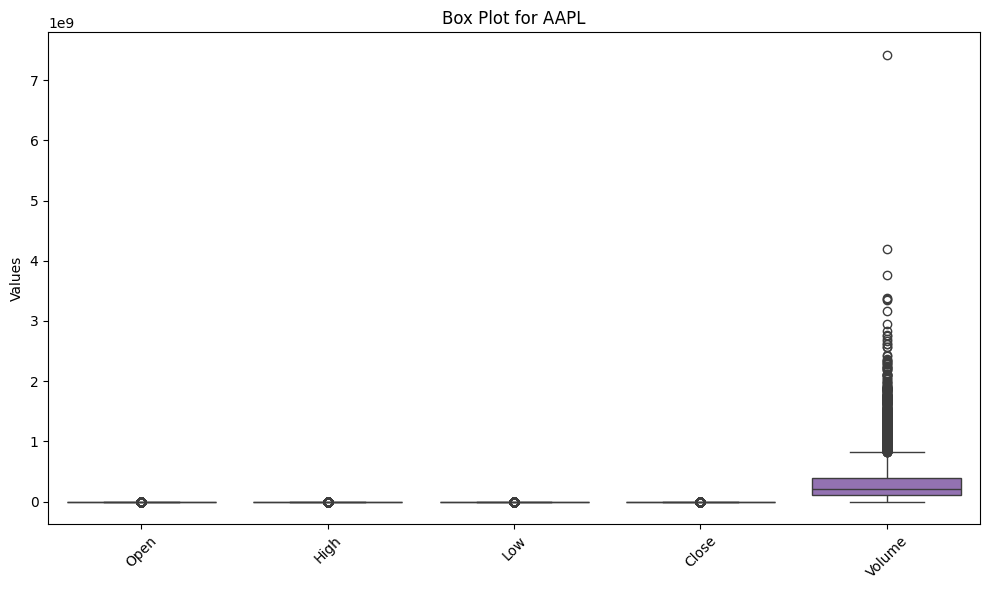

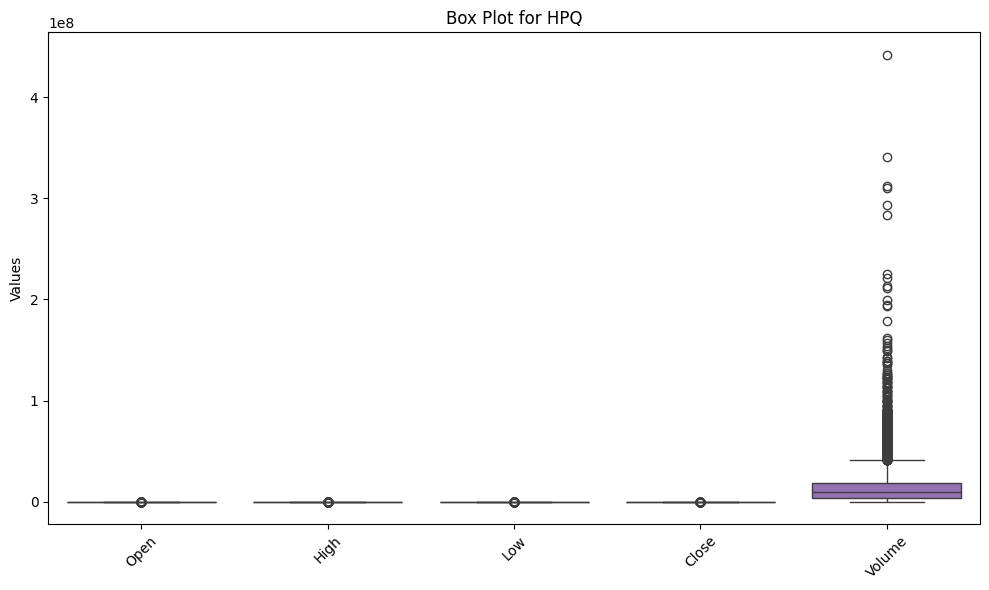

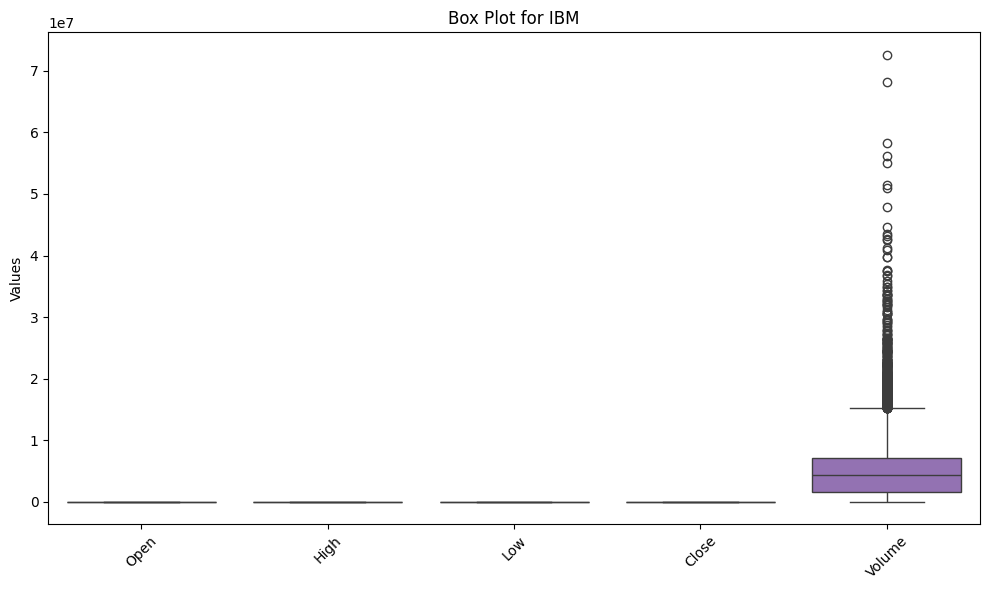

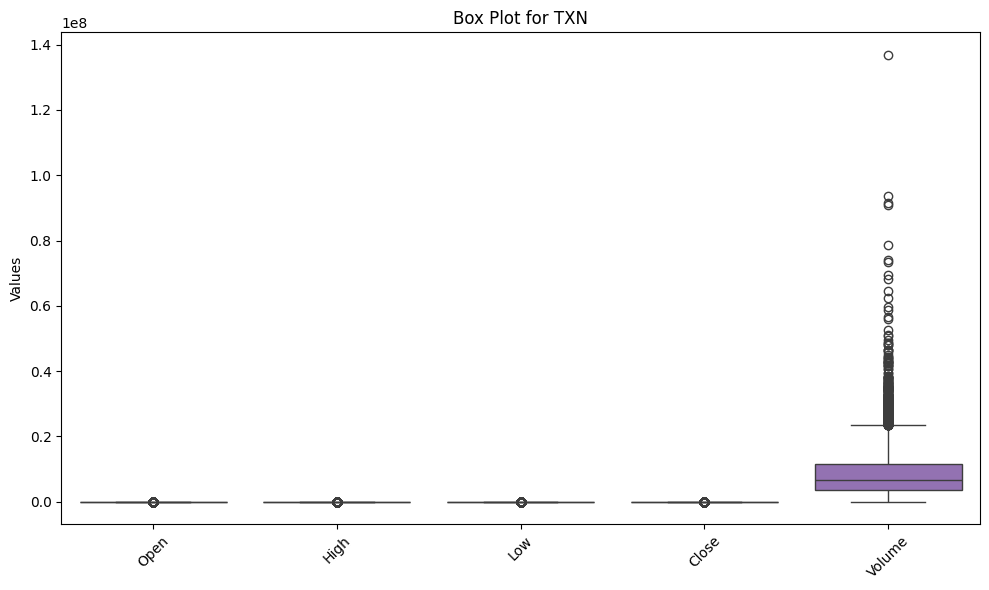

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_boxplot(data, company_name):
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=data[['Open', 'High', 'Low', 'Close', 'Volume']])
    plt.title(f'Box Plot for {company_name}')
    plt.ylabel('Values')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


plot_boxplot(df_aapl, 'AAPL')
plot_boxplot(df_hpq, 'HPQ')
plot_boxplot(df_ibm, 'IBM')
plot_boxplot(df_txn, 'TXN')


## Line Charts of Price Metrics
This visualization shows the trend of price metrics over time. It helps us see how the opening, closing, high, and low prices move together.

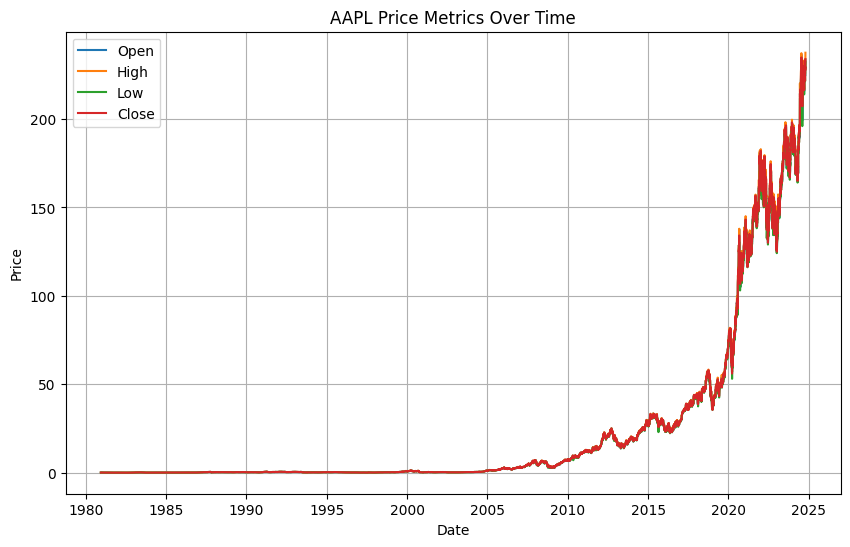

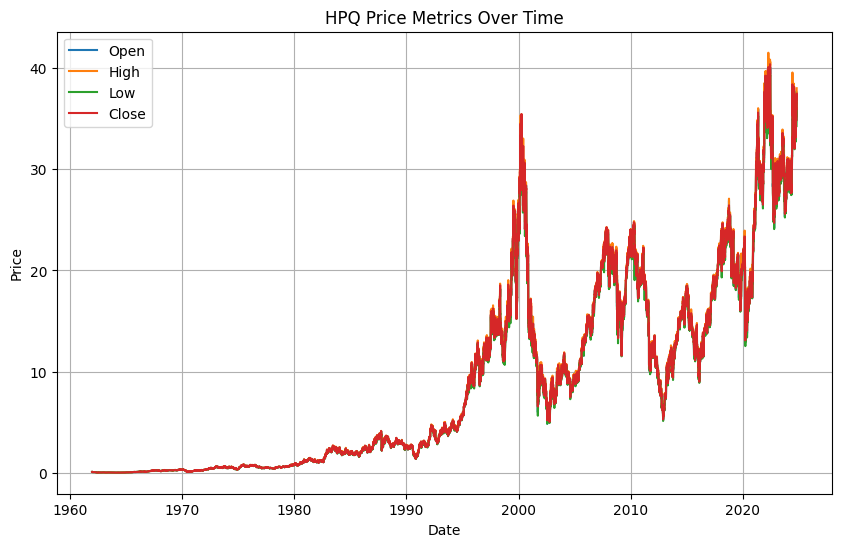

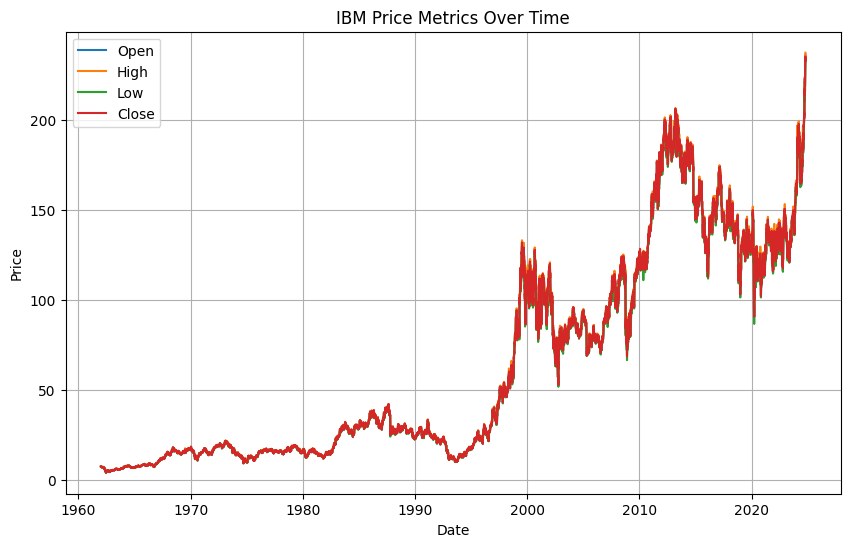

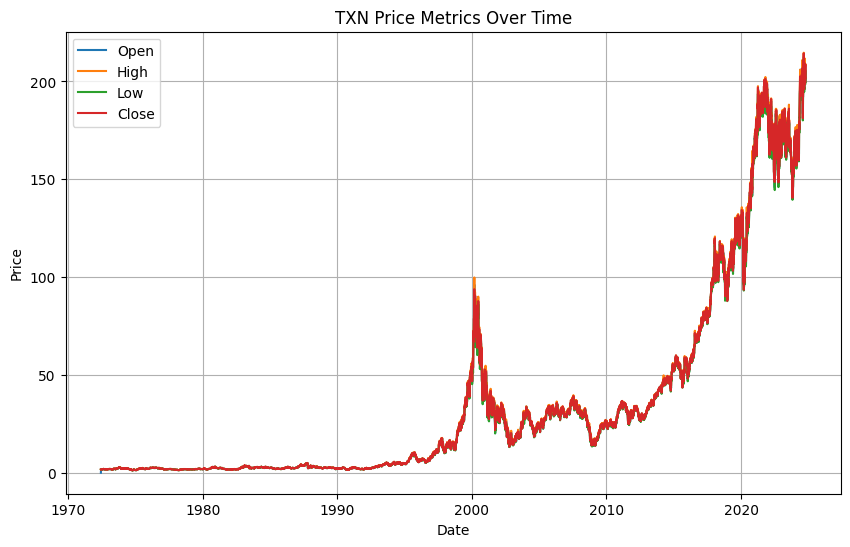

In [ ]:
import matplotlib.pyplot as plt

def plot_price_metrics(df, company_name):
    plt.figure(figsize=(10, 6))
    plt.plot(df['Date'], df['Open'], label='Open')
    plt.plot(df['Date'], df['High'], label='High')
    plt.plot(df['Date'], df['Low'], label='Low')
    plt.plot(df['Date'], df['Close'], label='Close')
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.title(f'{company_name} Price Metrics Over Time')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_price_metrics(df_aapl, 'AAPL')
plot_price_metrics(df_hpq, 'HPQ')
plot_price_metrics(df_ibm, 'IBM')
plot_price_metrics(df_txn, 'TXN')


## Volume vs. Price Scatter Plot
This scatter plot shows the relationship between volume and closing price. It visualizes if there’s any pattern indicating that volume changes impact the price.

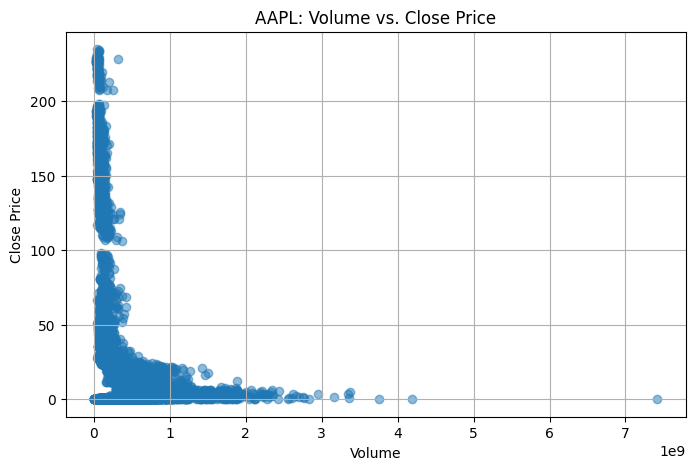

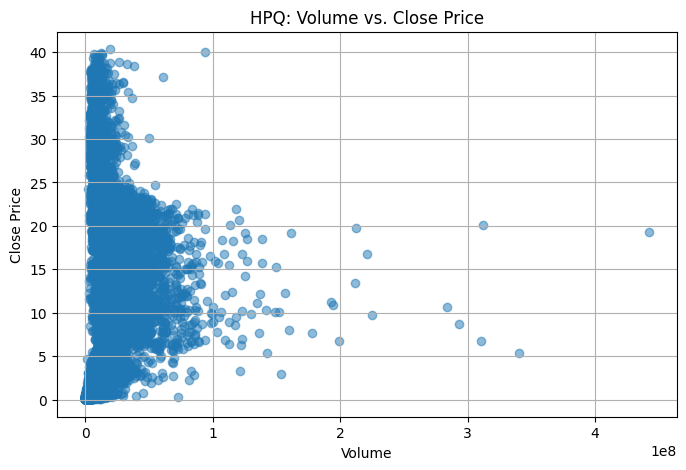

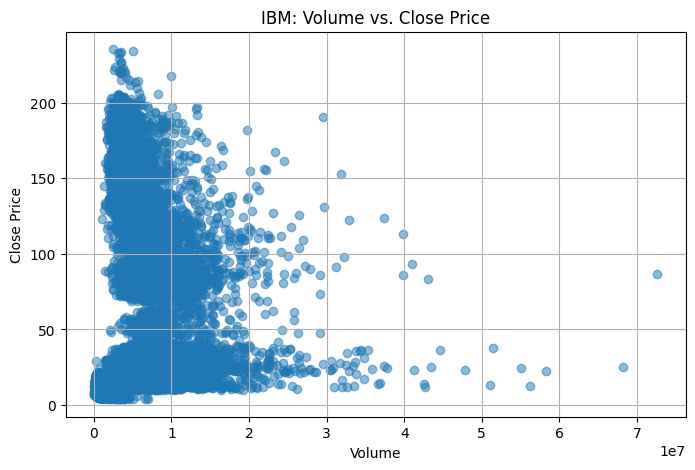

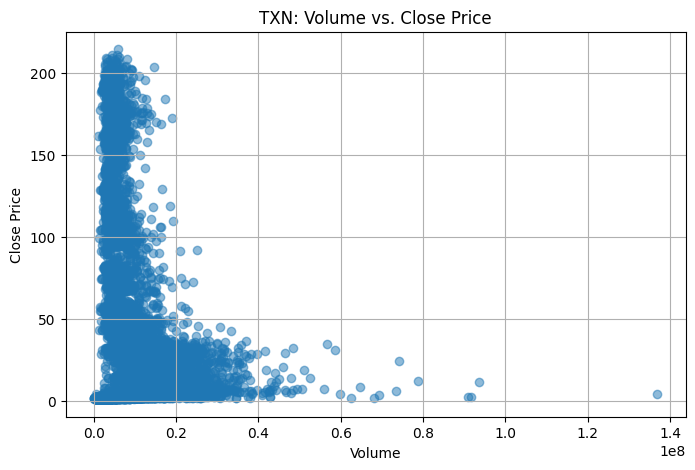

In [ ]:
def plot_volume_vs_price(df, company_name):
    plt.figure(figsize=(8, 5))
    plt.scatter(df['Volume'], df['Close'], alpha=0.5)
    plt.xlabel('Volume')
    plt.ylabel('Close Price')
    plt.title(f'{company_name}: Volume vs. Close Price')
    plt.grid(True)
    plt.show()

plot_volume_vs_price(df_aapl, 'AAPL')
plot_volume_vs_price(df_hpq, 'HPQ')
plot_volume_vs_price(df_ibm, 'IBM')
plot_volume_vs_price(df_txn, 'TXN')


<p align="justify">Across all three companies (HPQ, IBM, TXN), there is no consistent or strong relationship between trading volume and closing price. While there may be some instances where high volumes coincide with price fluctuations, the overall pattern remains weak, suggesting that other factors besides trading volume are driving the stock prices.</p>

# **REVIEW-II**

##Feature engineering

<p align="justify">Feature engineering is the process of creating new input features or modifying existing ones to improve the performance of machine learning models. It involves transforming raw data into meaningful features that capture the underlying patterns in the data, making it easier for models to learn from. This can include tasks such as scaling, normalization, encoding, and creating new features from existing data, such as moving averages or price changes in stock market prediction. Proper feature engineering helps improve model accuracy and efficiency.</p>



### Weekend effect

<p align="justify">The <strong>weekend effect</strong> in stock markets refers to the phenomenon where stock returns tend to be lower on Mondays compared to other days of the week, and sometimes higher on Fridays. This pattern is often attributed to investor behavior, such as negative sentiment over the weekend, which influences stock prices at the start of the trading week, and more optimistic sentiment as the market closes for the weekend on Fridays.</p>



<p align="justify">This code creates a new feature 'mon_fri' in the DataFrame df_txn, which marks whether the day of the transaction is a Monday (0) or Friday (4). For each row, it checks the 'Date' column, and if the transaction occurred on a Monday or Friday, the feature is set to 1; otherwise, it is set to 0. This feature helps to capture the potential weekend effect on stock prices by distinguishing between these two weekdays and the rest of the week.</p>


In [ ]:

df_txn['mon_fri'] = 0

for i in range(len(df_txn)):
    temp = pd.Timestamp(df_txn['Date'][i])
    if temp.dayofweek == 0 or temp.dayofweek == 4:
        df_txn.at[i, 'mon_fri'] = 1
    else:
        df_txn.at[i, 'mon_fri'] = 0


<h2>Box Plot<h2>
<p align="justify">This code generates a box plot to visualize the distribution of closing prices on Mondays and Fridays compared to other weekdays. It uses seaborn's boxplot function to plot 'Close' prices from df_txn, grouped by the 'mon_fri' feature, which indicates whether the day is a Monday/Friday or another day. The plot helps to identify any potential differences in the distribution of closing prices based on the day type, supporting the hypothesis of a weekend effect.</p>


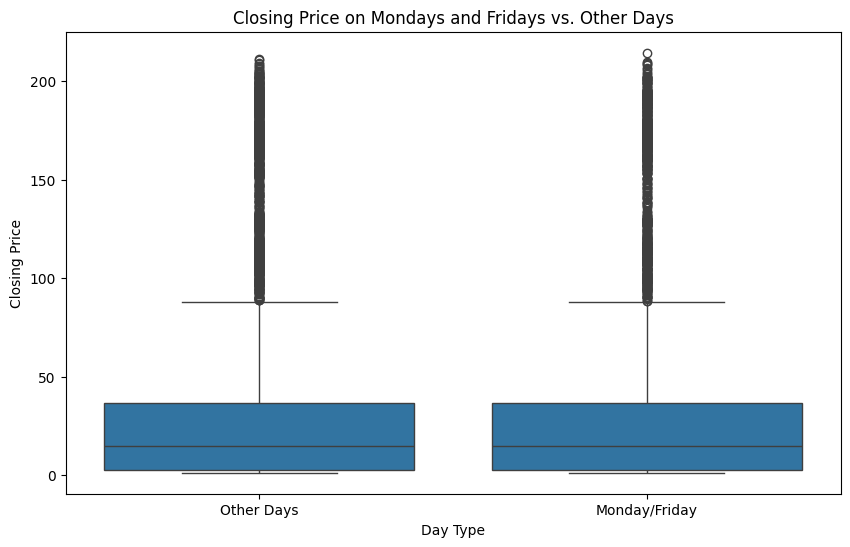

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_txn, x='mon_fri', y='Close')
plt.xticks([0, 1], ['Other Days', 'Monday/Friday'])
plt.xlabel('Day Type')
plt.ylabel('Closing Price')
plt.title('Closing Price on Mondays and Fridays vs. Other Days')
plt.show()


<h2>Line Plot<h2>
<p align="justify">This code generates a line plot of the 'Close' prices over time, with a scatter plot overlay highlighting the prices on Mondays and Fridays. The 'mon_fri' feature is used to identify Monday/Friday entries, which are marked in red on the plot. This visualization allows for an easy comparison of closing prices on these days against others, helping to identify trends or anomalies tied to weekdays.</p>


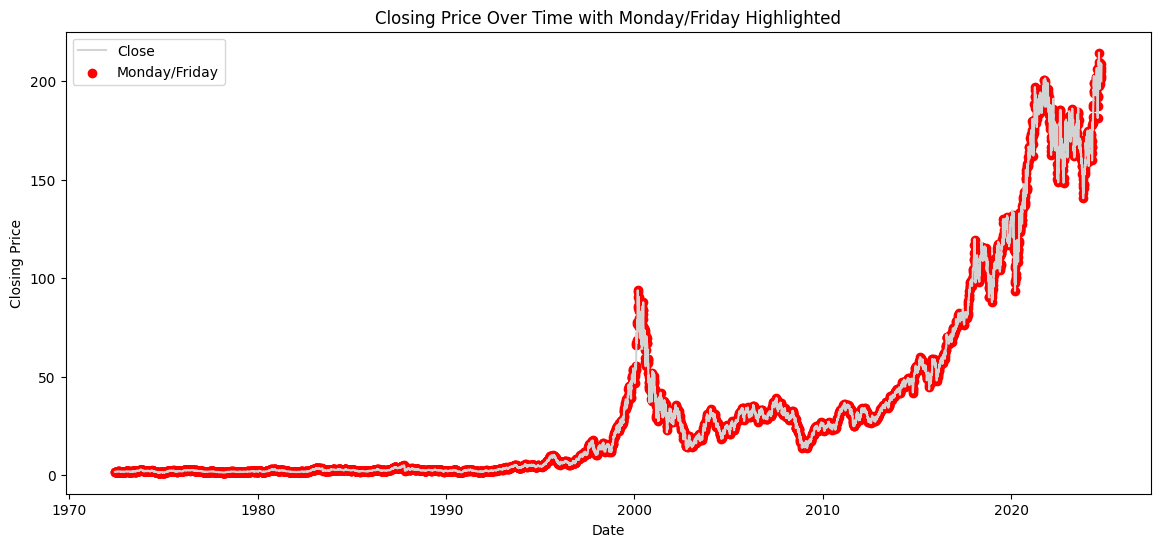

In [ ]:
plt.figure(figsize=(14, 6))
plt.plot(df_txn['Date'], df_txn['Close'], label='Close', color='lightgray')
plt.scatter(df_txn[df_txn['mon_fri'] == 1]['Date'],
            df_txn[df_txn['mon_fri'] == 1]['Close'],
            color='red', label='Monday/Friday')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.title('Closing Price Over Time with Monday/Friday Highlighted')
plt.legend()
plt.show()


<h2>Bar Plot<h2>
<p align="justify">This code calculates and visualizes the average closing prices for Mondays/Fridays and other days. A bar plot is generated to compare the average closing prices, highlighting any significant differences between the two groups. This helps in understanding the impact of weekday patterns on stock performance.</p>


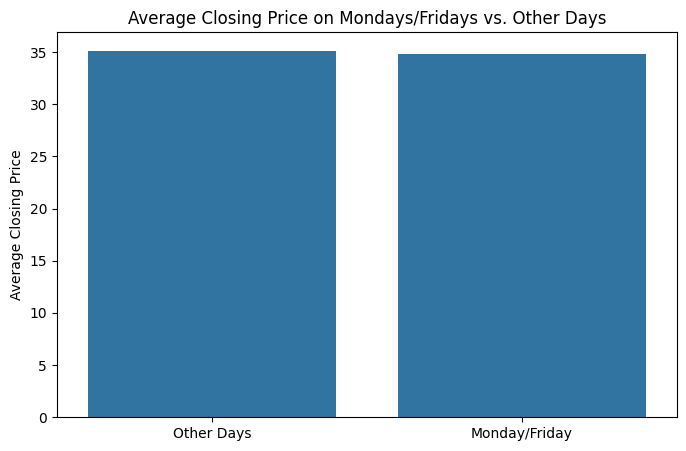

In [ ]:
avg_close = df_txn.groupby('mon_fri')['Close'].mean()

plt.figure(figsize=(8, 5))
sns.barplot(x=['Other Days', 'Monday/Friday'], y=avg_close)
plt.ylabel('Average Closing Price')
plt.title('Average Closing Price on Mondays/Fridays vs. Other Days')
plt.show()


<p align="justify">This cell removes the 'mon_fri' feature from the DataFrame after it has been used for analysis. Dropping this feature ensures that the dataset is cleaned and prepared for subsequent modeling or analysis steps.</p>


In [ ]:

df_txn = df_txn.drop('mon_fri', axis=1)
df_txn.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,1972-06-01,0.000000,1.704427,1.690104,1.701823,0.722893,825600
1,1972-06-02,1.720052,1.736979,1.720052,1.733073,0.736167,2496000
2,1972-06-05,1.733073,1.752604,1.729167,1.735677,0.737273,960000
3,1972-06-06,1.735677,1.739583,1.662760,1.662760,0.706299,1824000
4,1972-06-07,1.662760,1.670573,1.656250,1.656250,0.703534,604800


###Outlier detection

<p align="justify">Outlier detection is the process of identifying data points that significantly differ from the rest of the dataset. These outliers can indicate variability in the data, errors, or novel insights.</p>



<p align="justify">The Z-score method detects outliers by measuring how many standard deviations a data point is away from the mean. A Z-score greater than 3 (or less than -3) indicates that a data point is an outlier. In this case, outliers are identified for the 'Close' price in the dataset.</p>


In [ ]:
from scipy.stats import zscore

df_aapl['z_score'] = zscore(df_aapl['Close'])

outliers_z = df_aapl[df_aapl['z_score'].abs() > 3]
print(f'Z-Score Outliers Count: {len(outliers_z)}')


Z-Score Outliers Count: 437


<p align="justify">The IQR (Interquartile Range) method identifies outliers by calculating the range between the first (Q1) and third (Q3) quartiles of the data. Values outside the range defined by 1.5 times the IQR are considered outliers. This method is applied to the 'Close' price to detect extreme values.</p>


In [ ]:

Q1 = df_aapl['Close'].quantile(0.25)
Q3 = df_aapl['Close'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = df_aapl[(df_aapl['Close'] < lower_bound) | (df_aapl['Close'] > upper_bound)]
print(f'IQR Method Outliers Count: {len(outliers_iqr)}')


IQR Method Outliers Count: 1380


<p align="justify">A box plot provides a graphical representation of the distribution of data, highlighting the median, quartiles, and potential outliers. The box plot for 'Close' price helps visually identify any values outside the typical range, suggesting the presence of outliers.</p>


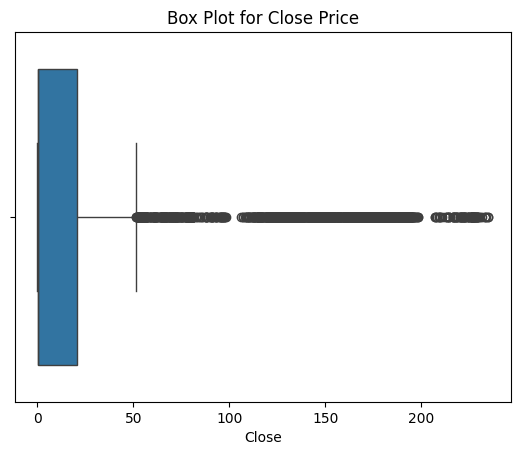

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df_aapl['Close'])
plt.title('Box Plot for Close Price')
plt.show()


<p align="justify">The Mahalanobis Distance method detects outliers by measuring how far a point is from the mean in terms of the covariance matrix. Points with a Mahalanobis distance above a defined threshold are considered outliers. Here, the method is applied to both 'Close' price and 'Volume' to identify multivariate outliers.</p>


In [ ]:
import numpy as np
from scipy.stats import chi2

X = df_aapl[['Close', 'Volume']].dropna()

cov_matrix = np.cov(X.T)

inv_cov_matrix = np.linalg.inv(cov_matrix)

mean = np.mean(X, axis=0)
diff = X - mean
md = np.sqrt(np.sum(np.dot(diff, inv_cov_matrix) * diff, axis=1))

threshold = chi2.ppf(0.99, df=X.shape[1])

outliers_mahalanobis = X[md > threshold]
print(f'Mahalanobis Distance Outliers Count: {len(outliers_mahalanobis)}')


Mahalanobis Distance Outliers Count: 6


<p align="justify">DBSCAN (Density-Based Spatial Clustering of Applications with Noise) is a clustering method that identifies outliers based on the density of points. Points that do not belong to any cluster are marked as outliers. In this case, DBSCAN is used to identify outliers in the 'Close' price and 'Volume' data.</p>


In [ ]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.5, min_samples=5)

outliers_dbscan = dbscan.fit_predict(X)

outliers_dbscan_data = X[outliers_dbscan == -1]
print(f'DBSCAN Outliers Count: {len(outliers_dbscan_data)}')


DBSCAN Outliers Count: 11023


<p align="justify">A summary of the number of outliers detected by each method is provided, offering insights into the distribution of outliers within the dataset. This includes Z-score, IQR, Mahalanobis Distance, and DBSCAN methods, each highlighting different aspects of the data's distribution.</p>


In [ ]:

outliers_summary = {
    'Z-Score Outliers': len(outliers_z),
    'IQR Method Outliers': len(outliers_iqr),
    'Mahalanobis Distance Outliers': len(outliers_mahalanobis),
    'DBSCAN Outliers': len(outliers_dbscan_data)
}
print("\nOutlier Counts for Each Method:")
for method, count in outliers_summary.items():
    print(f'{method}: {count}')



Outlier Counts for Each Method:
Z-Score Outliers: 437
IQR Method Outliers: 1380
Mahalanobis Distance Outliers: 6
DBSCAN Outliers: 11023


<p align="justify">Outliers in stock data are quite common due to various factors such as market volatility, sudden news events, or market anomalies. While detecting outliers is important for understanding data distribution and ensuring model robustness, in this case, we might not remove outliers since they can reflect significant market movements. In stock market prediction, outliers often carry valuable information about market trends and investor behavior. Therefore, instead of removing them, it’s essential to analyze and understand their impact on model performance.</p>


## Distribution Transformation and Skewness Correction

<p align="justify"> This process involves applying mathematical transformations (such as log, square root, or Box-Cox) to adjust the data distribution, aiming to reduce skewness and make the data more symmetric. The goal is to make the data more suitable for statistical and machine learning models that assume normality or require a less skewed distribution.</p>

<p align="justify">This code calculates the skewness of the 'Close' price from the AAPL dataset using the <code>skew</code> function from the <code>scipy.stats</code> library. Skewness measures the asymmetry of the distribution of data. A positive skew indicates that the data has a longer right tail, while a negative skew indicates a longer left tail. In this case, the <code>bias=False</code> argument ensures an unbiased estimate of skewness.</p>


In [ ]:
from scipy.stats import skew

skewness = skew(df_aapl['Close'], bias=False)
print(f"Skewness of 'Close': {skewness}")


Skewness of 'Close': 2.5045276102319933


<p align="justify"> This code generates a histogram with a Kernel Density Estimate (KDE) plot for the 'Close' column in the `df_aapl` DataFrame. The histogram displays the frequency distribution of closing prices, while the KDE curve provides a smoothed representation of the distribution. The plot is titled "Distribution of Close Prices" to visually assess the shape and spread of the data.</p>

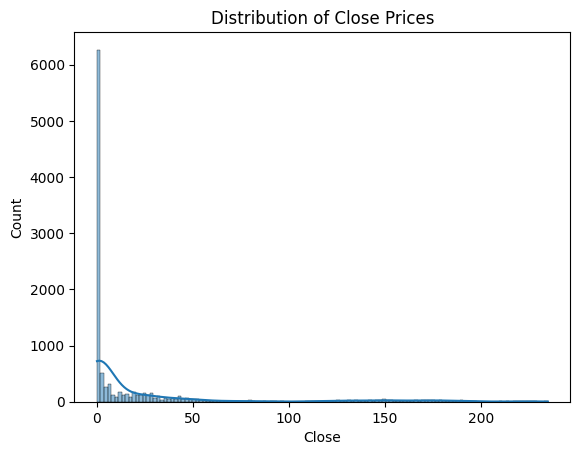

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df_aapl['Close'], kde=True)
plt.title('Distribution of Close Prices')
plt.show()


This code performs three common transformations on the 'Close' column in the `df_aapl` DataFrame to correct skewness:

1. **Log Transformation**: Adds 1 to the 'Close' values and applies the natural logarithm, stored in the new column 'Close_log'.
2. **Square Root Transformation**: Takes the square root of the 'Close' values and stores them in the 'Close_sqrt' column.
3. **Box-Cox Transformation**: Applies the Box-Cox transformation to the 'Close' values (after adding 1 to avoid non-positive values), and stores the result in 'Close_boxcox'.

These transformations aim to reduce skewness and make the data more normally distributed for further analysis.

In [ ]:
import numpy as np
from scipy.stats import boxcox

df_aapl['Close_log'] = np.log(df_aapl['Close'] + 1)
df_aapl['Close_sqrt'] = np.sqrt(df_aapl['Close'])
df_aapl['Close_boxcox'], _ = boxcox(df_aapl['Close'] + 1)


This code calculates the skewness of the 'Close' column in the `df_aapl` DataFrame before and after applying various transformations:

1. **Original Skewness**: Calculates the skewness of the original 'Close' data.
2. **Log Transformation Skewness**: Calculates the skewness of the 'Close_log' column after applying the log transformation.
3. **Square Root Transformation Skewness**: Calculates the skewness of the 'Close_sqrt' column after applying the square root transformation.
4. **Box-Cox Transformation Skewness**: Calculates the skewness of the 'Close_boxcox' column after applying the Box-Cox transformation.

The printed results help assess how each transformation affects the distribution's symmetry and the success of skewness correction.







In [ ]:

skew_original = df_aapl['Close'].skew()
skew_log = df_aapl['Close_log'].skew()
skew_sqrt = df_aapl['Close_sqrt'].skew()
skew_boxcox = pd.Series(df_aapl['Close_boxcox']).skew()

print(f"Original Skewness: {skew_original}")
print(f"Log Transformation Skewness: {skew_log}")
print(f"Square Root Transformation Skewness: {skew_sqrt}")
print(f"Box-Cox Transformation Skewness: {skew_boxcox}")


Original Skewness: 2.5045276102319933
Log Transformation Skewness: 0.8535555176510303
Square Root Transformation Skewness: 1.6211545809555206
Box-Cox Transformation Skewness: 0.43527466713563334


This code generates a 2x2 grid of histograms to compare the 'Close' price distribution in `df_aapl` before and after applying

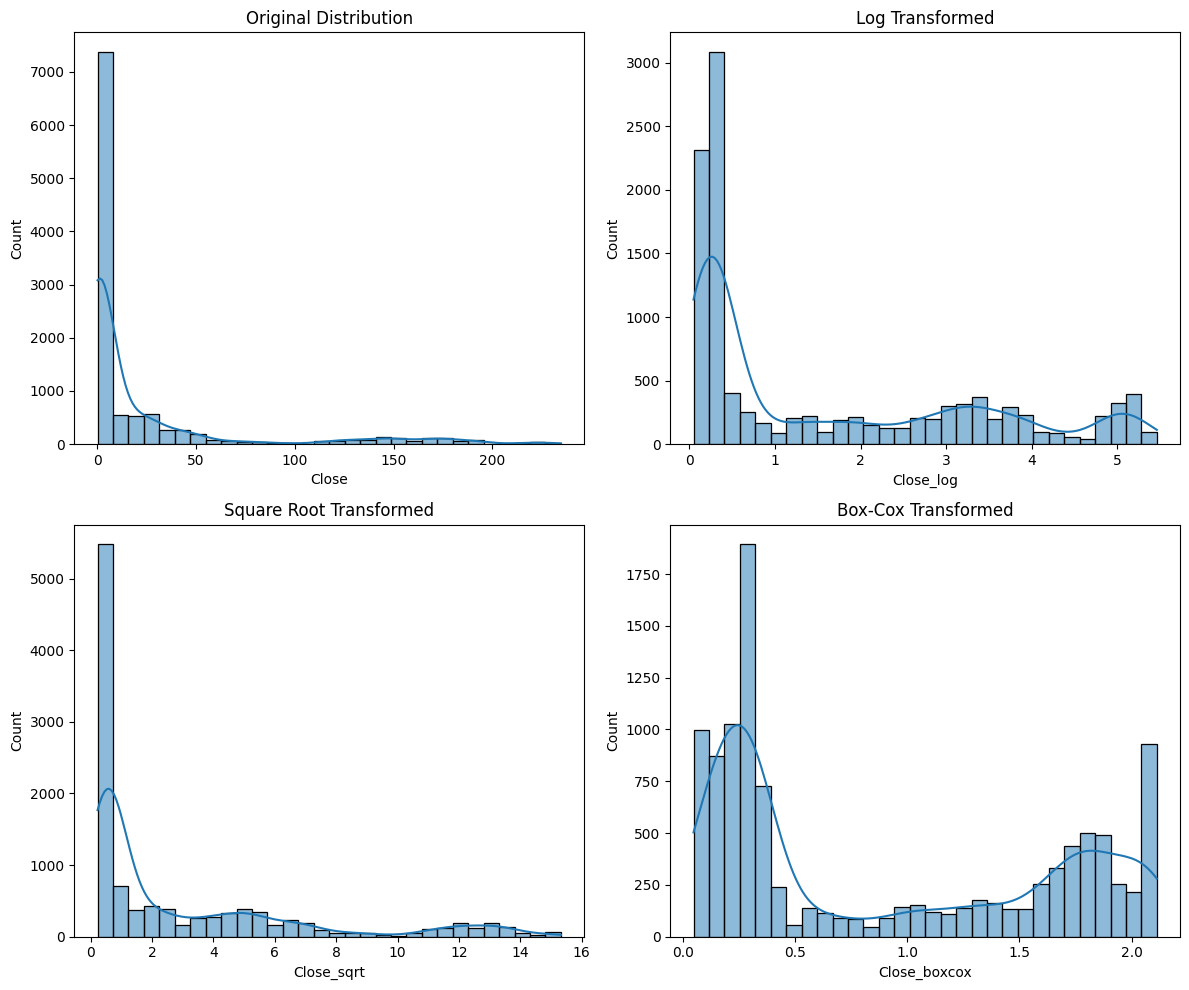

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
sns.histplot(df_aapl['Close'], ax=axes[0, 0], kde=True, bins=30).set_title("Original Distribution")
sns.histplot(df_aapl['Close_log'], ax=axes[0, 1], kde=True, bins=30).set_title("Log Transformed")
sns.histplot(df_aapl['Close_sqrt'], ax=axes[1, 0], kde=True, bins=30).set_title("Square Root Transformed")
sns.histplot(df_aapl['Close_boxcox'], ax=axes[1, 1], kde=True, bins=30).set_title("Box-Cox Transformed")
plt.tight_layout()
plt.show()


Calculates the skewness for all numerical columns in the `df_aapl` DataFrame, indicating the distribution's asymmetry (positive for right skew, negative for left skew).

In [ ]:
skewness = df_aapl.skew(numeric_only=True)
print(skewness)


Open            2.504632
High            2.502208
Low             2.506714
Close           2.504528
Adj Close       2.550677
Volume          3.565699
Close_log       0.853556
Close_sqrt      1.621155
Close_boxcox    0.435275
dtype: float64


- **Log**: Applied to 'Open', 'High', 'Low', 'Adj Close', and 'Volume' for skewness reduction.
- **Square Root**: Applied to the same columns to stabilize variance.
- **Box-Cox**: Used on 'Open', 'High', 'Low', 'Adj Close' for normality enhancement.

In [ ]:

df_aapl['Open_log'] = np.log(df_aapl['Open'])
df_aapl['High_log'] = np.log(df_aapl['High'])
df_aapl['Low_log'] = np.log(df_aapl['Low'])
df_aapl['Adj Close_log'] = np.log(df_aapl['Adj Close'])
df_aapl['Volume_log'] = np.log(df_aapl['Volume'])


df_aapl['Open_sqrt'] = np.sqrt(df_aapl['Open'])
df_aapl['High_sqrt'] = np.sqrt(df_aapl['High'])
df_aapl['Low_sqrt'] = np.sqrt(df_aapl['Low'])
df_aapl['Adj Close_sqrt'] = np.sqrt(df_aapl['Adj Close'])
df_aapl['Volume_sqrt'] = np.sqrt(df_aapl['Volume'])

from scipy.stats import boxcox
df_aapl['Open_boxcox'], _ = boxcox(df_aapl['Open'])
df_aapl['High_boxcox'], _ = boxcox(df_aapl['High'])
df_aapl['Low_boxcox'], _ = boxcox(df_aapl['Low'])
df_aapl['Adj Close_boxcox'], _ = boxcox(df_aapl['Adj Close'])



This helps compare how the transformations reduce skewness in the data, aiming for a more normal distribution.

In [ ]:

skewness_before = df_aapl[['Open', 'High', 'Low', 'Adj Close', 'Volume']].skew()
skewness_after = df_aapl[['Open_log', 'High_log', 'Low_log', 'Adj Close_log',
                          'Open_sqrt', 'High_sqrt', 'Low_sqrt', 'Adj Close_sqrt', 'Volume_sqrt',
                          'Open_boxcox', 'High_boxcox', 'Low_boxcox', 'Adj Close_boxcox']].skew()

print("Skewness Before Transformation:\n", skewness_before)
print("\nSkewness After Transformation:\n", skewness_after)


Skewness Before Transformation:
 Open         2.504632
High         2.502208
Low          2.506714
Adj Close    2.550677
Volume       3.565699
dtype: float64

Skewness After Transformation:
 Open_log            0.482872
High_log            0.481997
Low_log             0.484246
Adj Close_log       0.494009
Open_sqrt           1.620771
High_sqrt           1.621456
Low_sqrt            1.620661
Adj Close_sqrt      1.679402
Volume_sqrt         1.299776
Open_boxcox         0.181226
High_boxcox         0.179749
Low_boxcox          0.182882
Adj Close_boxcox    0.180085
dtype: float64


- Applied Box-Cox transformation to the 'Open', 'High', 'Low', 'Adj Close', and 'Close' columns.
- Recalculated skewness after the transformation to reduce skew and normalize the data for modeling.

In [ ]:
from scipy import stats

df_aapl['Open_boxcox'], _ = stats.boxcox(df_aapl['Open'] + 1)
df_aapl['High_boxcox'], _ = stats.boxcox(df_aapl['High'] + 1)
df_aapl['Low_boxcox'], _ = stats.boxcox(df_aapl['Low'] + 1)
df_aapl['Adj Close_boxcox'], _ = stats.boxcox(df_aapl['Adj Close'] + 1)
df_aapl['Close_boxcox'], _ = stats.boxcox(df_aapl['Close'] + 1)

skewness_after_boxcox = df_aapl[['Open_boxcox', 'High_boxcox', 'Low_boxcox', 'Adj Close_boxcox', 'Close_boxcox']].skew()

print("Skewness After Box-Cox Transformation:")
print(skewness_after_boxcox)


Skewness After Box-Cox Transformation:
Open_boxcox         0.435237
High_boxcox         0.433381
Low_boxcox          0.437331
Adj Close_boxcox    0.458762
Close_boxcox        0.435275
dtype: float64


In [ ]:
df_aapl

,Date,Open,High,Low,Close,Adj Close,Volume,Close_log,Close_sqrt,Close_boxcox,...,Volume_log,Open_sqrt,High_sqrt,Low_sqrt,Adj Close_sqrt,Volume_sqrt,Open_boxcox,High_boxcox,Low_boxcox,Adj Close_boxcox
0,1980-12-12,0.128348,0.128906,0.128348,0.128348,0.098943,469033600,0.120755,0.358257,0.117689,...,19.966185,0.358257,0.359035,0.358257,0.314552,21657.183566,0.117689,0.118173,0.117674,0.092374
1,1980-12-15,0.122210,0.122210,0.121652,0.121652,0.093781,175884800,0.114803,0.348786,0.112030,...,18.985340,0.349585,0.349585,0.348786,0.306237,13262.156687,0.112503,0.112516,0.112016,0.087857
2,1980-12-16,0.113281,0.113281,0.112723,0.112723,0.086898,105728000,0.106810,0.335742,0.104407,...,18.476380,0.336572,0.336572,0.335742,0.294785,10282.412168,0.104886,0.104897,0.104395,0.081785
3,1980-12-17,0.115513,0.116071,0.115513,0.115513,0.089049,86441600,0.109314,0.339872,0.106798,...,18.274980,0.339872,0.340692,0.339872,0.298410,9297.397485,0.106798,0.107287,0.106786,0.083688
4,1980-12-18,0.118862,0.119420,0.118862,0.118862,0.091630,73449600,0.112312,0.344764,0.109657,...,18.112110,0.344764,0.345572,0.344764,0.302705,8570.274208,0.109657,0.110145,0.109644,0.085966
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11047,2024-10-09,225.229996,229.750000,224.830002,229.539993,229.539993,33591100,5.440424,15.150577,2.109861,...,17.329772,15.007665,15.157506,14.994332,15.150577,5795.782950,2.108067,2.117284,2.099768,2.030366
11048,2024-10-10,227.779999,229.500000,227.169998,229.039993,229.039993,28183500,5.438253,15.134067,2.109649,...,17.154247,15.092382,15.149257,15.072160,15.134067,5308.813427,2.109167,2.117177,2.100768,2.030178
11049,2024-10-11,229.300003,229.410004,227.339996,227.550003,227.550003,31759200,5.431755,15.084761,2.109013,...,17.273693,15.142655,15.146287,15.077798,15.084761,5635.530144,2.109815,2.117138,2.100841,2.029615
11050,2024-10-14,228.699997,231.729996,228.600006,231.300003,231.300003,39882100,5.448030,15.208550,2.110602,...,17.501438,15.122830,15.222680,15.119524,15.208550,6315.227629,2.109560,2.118125,2.101373,2.031022


## Feature Selection

- Used `SelectKBest` with `f_regression` to select the top 3 features that best predict the 'Close_boxcox' variable.
- Displayed the selected features and their corresponding feature scores.

In [ ]:
from sklearn.feature_selection import SelectKBest, f_regression

X = df_aapl[['Open_boxcox', 'High_boxcox', 'Low_boxcox', 'Adj Close_boxcox']]
y = df_aapl['Close_boxcox']

selector = SelectKBest(score_func=f_regression, k=3)
X_new = selector.fit_transform(X, y)

selected_features = X.columns[selector.get_support()]
feature_scores = selector.scores_[selector.get_support()]

print("Selected Features:")
print(selected_features)

print("\nFeature Scores:")
print(feature_scores)


Selected Features:
Index(['Open_boxcox', 'High_boxcox', 'Low_boxcox'], dtype='object')

Feature Scores:
[1.93005297e+08 3.71938583e+08 3.52043678e+08]


- Applied `SelectKBest` with `f_regression` to select the top 3 features from both the original and Box-Cox transformed data to predict the 'Close' variable.
- Printed the selected features and their corresponding feature scores.

In [ ]:
from sklearn.feature_selection import SelectKBest, f_regression

X = df_aapl[['Open', 'High', 'Low', 'Adj Close', 'Open_boxcox', 'High_boxcox', 'Low_boxcox', 'Adj Close_boxcox']]
y = df_aapl['Close']

selector = SelectKBest(score_func=f_regression, k=3)
X_new = selector.fit_transform(X, y)

selected_features = X.columns[selector.get_support()]
feature_scores = selector.scores_[selector.get_support()]

print("Selected Features:")
print(selected_features)

print("\nFeature Scores:")
print(feature_scores)


Selected Features:
Index(['Open', 'High', 'Low'], dtype='object')

Feature Scores:
[45116779.93940485 97573953.46071339 96325415.11638397]


Created a cleaned DataFrame `df_aapl_cleaned` by selecting specific columns.

In [ ]:

df_aapl_cleaned = df_aapl[['Date', 'Open', 'High', 'Low', 'Adj Close', 'Close', 'Volume',
                           'Open_boxcox', 'High_boxcox', 'Low_boxcox', 'Adj Close_boxcox',
                           'Close_boxcox']]

print(df_aapl_cleaned.head())


         Date      Open      High       Low  Adj Close     Close     Volume  \
0  1980-12-12  0.128348  0.128906  0.128348   0.098943  0.128348  469033600   
1  1980-12-15  0.122210  0.122210  0.121652   0.093781  0.121652  175884800   
2  1980-12-16  0.113281  0.113281  0.112723   0.086898  0.112723  105728000   
3  1980-12-17  0.115513  0.116071  0.115513   0.089049  0.115513   86441600   
4  1980-12-18  0.118862  0.119420  0.118862   0.091630  0.118862   73449600   

   Open_boxcox  High_boxcox  Low_boxcox  Adj Close_boxcox  Close_boxcox  
0     0.117689     0.118173    0.117674          0.092374      0.117689  
1     0.112503     0.112516    0.112016          0.087857      0.112030  
2     0.104886     0.104897    0.104395          0.081785      0.104407  
3     0.106798     0.107287    0.106786          0.083688      0.106798  
4     0.109657     0.110145    0.109644          0.085966      0.109657  


## Train Validation Test Split

The code splits the data into training, validation, and test sets. The features `X` and target `Y` are split as follows:

- 70% for training (`X_train`, `Y_train`)
- 15% for validation (`X_val`, `Y_val`)
- 15% for testing (`X_test`, `Y_test`)

The split is done using a 30% test size, followed by splitting the remaining 70% into validation and test sets without shuffling (time series data).







In [ ]:
from sklearn.model_selection import train_test_split

X = df_aapl_cleaned[['Open_boxcox', 'High_boxcox', 'Low_boxcox']]
Y = df_aapl_cleaned['Close_boxcox']

X_train, X_temp, Y_train, Y_temp = train_test_split(X, Y, test_size=0.3, shuffle=False)
X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, shuffle=False)

print(f"Training set: {X_train.shape}, Validation set: {X_val.shape}, Test set: {X_test.shape}")


Training set: (7736, 3), Validation set: (1658, 3), Test set: (1658, 3)


## Linear Regression

<p align="justify">The code trains a Linear Regression model using the training data, computes the regression line's slope and intercept, and prints the equation for the fitted line.</p>

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

regressor = LinearRegression()
regressor.fit(X_train, Y_train)

slope = regressor.coef_
intercept = regressor.intercept_

print(f"Regression Line: Y = {slope[0]}X + {intercept}")


Regression Line: Y = -0.5732388990999815X + -0.00037030762213852153


In [ ]:
print(f"Regression Line: Y = ", end="")
for i, coef in enumerate(slope):
    print(f"{coef}X{i+1}", end=" + " if i < len(slope) - 1 else "\n")
print(f"Intercept: {intercept}")


Regression Line: Y = -0.5732388990999815X1 + 0.8274121899275464X2 + 0.7460546317902942X3
Intercept: -0.00037030762213852153


<p align="justify">This code predicts the target values for the training set using the Linear Regression model, calculates the Root Mean Squared Error (RMSE) to evaluate model performance, and prints the result.</p>

In [ ]:

Y_train_pred = regressor.predict(X_train)

rmse_train = np.sqrt(mean_squared_error(Y_train, Y_train_pred))
print(f"RMSE for training data: {rmse_train}")


RMSE for training data: 0.0028768032745404254


<p align="justify">This code visualizes the actual versus predicted target values for the training set using a scatter plot and overlays the regression line, helping to assess the model's prediction quality.</p>

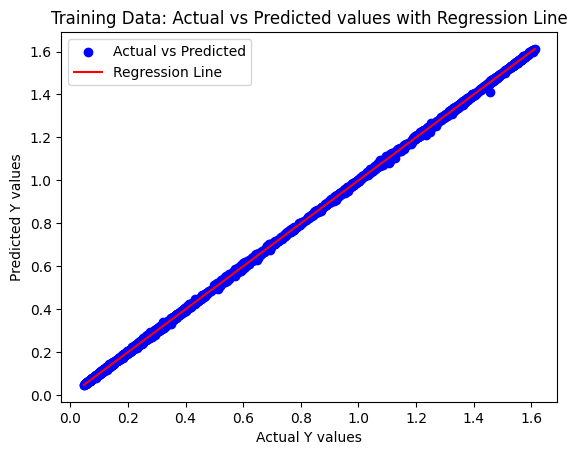

In [ ]:

plt.scatter(Y_train, Y_train_pred, color='blue', label='Actual vs Predicted')
plt.plot([min(Y_train), max(Y_train)], [min(Y_train_pred), max(Y_train_pred)], color='red', label='Regression Line')

plt.xlabel('Actual Y values')
plt.ylabel('Predicted Y values')
plt.title('Training Data: Actual vs Predicted values with Regression Line')
plt.legend()
plt.show()


<p align="justify">This code evaluates the model's performance on the validation set by calculating the R² score and RMSE, providing insights into prediction accuracy and error magnitude.</p>

In [ ]:

Y_val_pred = regressor.predict(X_val)

r2_val = r2_score(Y_val, Y_val_pred)
rmse_val = np.sqrt(mean_squared_error(Y_val, Y_val_pred))

print(f"Validation R²: {r2_val}")
print(f"Validation RMSE: {rmse_val}")


Validation R²: 0.9997167239541681
Validation RMSE: 0.0012907749798401894


<p align="justify">This code computes R² and RMSE to assess the model's performance on the test set and visualizes the relationship between actual and predicted values with a regression line.</p>

Test R²: 0.9998274282287134
Test RMSE: 0.0010205305031258892


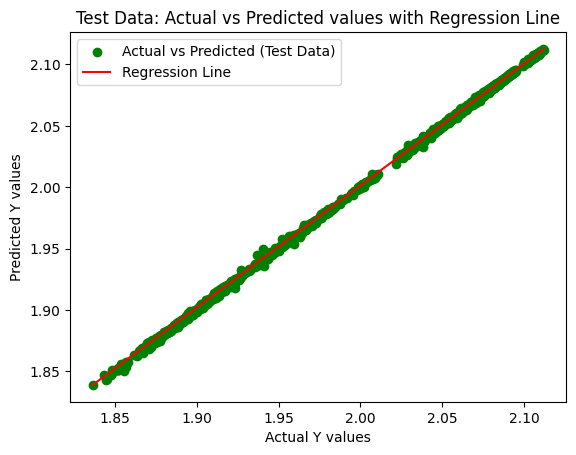

In [ ]:

Y_test_pred = regressor.predict(X_test)

r2_test = r2_score(Y_test, Y_test_pred)
rmse_test = np.sqrt(mean_squared_error(Y_test, Y_test_pred))

print(f"Test R²: {r2_test}")
print(f"Test RMSE: {rmse_test}")

plt.scatter(Y_test, Y_test_pred, color='green', label='Actual vs Predicted (Test Data)')
plt.plot([min(Y_test), max(Y_test)], [min(Y_test_pred), max(Y_test_pred)], color='red', label='Regression Line')

plt.xlabel('Actual Y values')
plt.ylabel('Predicted Y values')
plt.title('Test Data: Actual vs Predicted values with Regression Line')
plt.legend()
plt.show()


<p align="justify">This code calculates the Mean Absolute Percentage Error (MAPE) for the training, validation, and test datasets to evaluate the model's prediction accuracy.</p>

In [ ]:
import numpy as np

mape_train = np.mean(np.abs((Y_train - Y_train_pred) / Y_train)) * 100
print(f"MAPE for training data: {mape_train}%")

mape_val = np.mean(np.abs((Y_val - Y_val_pred) / Y_val)) * 100
print(f"MAPE for validation data: {mape_val}%")

mape_test = np.mean(np.abs((Y_test - Y_test_pred) / Y_test)) * 100
print(f"MAPE for test data: {mape_test}%")


MAPE for training data: 0.5833613818966066%
MAPE for validation data: 0.05549980508300262%
MAPE for test data: 0.03501661671605141%


<p align="justify">This code computes the R² (coefficient of determination) values for the training, validation, and test datasets, assessing the proportion of variance in the target variable explained by the model.</p>

In [ ]:

r2_train = r2_score(Y_train, Y_train_pred)
r2_val = r2_score(Y_val, Y_val_pred)
r2_test = r2_score(Y_test, Y_test_pred)

print(f"Training R²: {r2_train}")
print(f"Validation R²: {r2_val}")
print(f"Test R²: {r2_test}")


Training R²: 0.9999527142613498
Validation R²: 0.9997167239541681
Test R²: 0.9998274282287134


In [ ]:
import numpy as np

def predict_output(input_features):
    input_data = np.array(input_features).reshape(1, -1)
    prediction = regressor.predict(input_data)

    return prediction[0]

input_features = [226.40, 226.92, 223.41] #225
#input_features = [236.18, 236.18, 234.01] # 235
predicted_output = predict_output(input_features)

print(f"Predicted Close price: {predicted_output}")

Predicted Close price: 224.65078236277049


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import time

# Start timing
train_start = time.time()
regressor.fit(X_train, Y_train)
train_end = time.time()

# Training time
training_time = train_end - train_start

# Predictions
val_start = time.time()
Y_val_pred = regressor.predict(X_val)
val_end = time.time()

test_start = time.time()
Y_test_pred = regressor.predict(X_test)
test_end = time.time()

# Validation and testing time
validation_time = val_end - val_start
testing_time = test_end - test_start

# Metrics computation function
def compute_metrics(actual, predicted, label):
    mae = mean_absolute_error(actual, predicted)
    mse = mean_squared_error(actual, predicted)
    rmse = np.sqrt(mse)
    r2 = r2_score(actual, predicted)
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    accuracy = 1 - (mape / 100)

    print(f"{label} MAE: {mae}")
    print(f"{label} MSE: {mse}")
    print(f"{label} RMSE: {rmse}")
    print(f"{label} R²: {r2}")
    print(f"{label} MAPE: {mape}%")
    print(f"{label} Accuracy: {accuracy * 100}%\n")

compute_metrics(Y_train, regressor.predict(X_train), "Training")

compute_metrics(Y_val, Y_val_pred, "Validation")

compute_metrics(Y_test, Y_test_pred, "Test")

print(f"Training time: {training_time} seconds")
print(f"Validation time: {validation_time} seconds")
print(f"Testing time: {testing_time} seconds")


Training MAE: 0.0018909534114282334
Training MSE: 8.275997080406515e-06
Training RMSE: 0.0028768032745404254
Training R²: 0.9999527142613498
Training MAPE: 0.5833613818966066%
Training Accuracy: 99.41663861810339%

Validation MAE: 0.0009581758171539723
Validation MSE: 1.6661000485814415e-06
Validation RMSE: 0.0012907749798401894
Validation R²: 0.9997167239541681
Validation MAPE: 0.05549980508300262%
Validation Accuracy: 99.944500194917%

Test MAE: 0.0006976650832859664
Test MSE: 1.0414825078103804e-06
Test RMSE: 0.0010205305031258892
Test R²: 0.9998274282287134
Test MAPE: 0.03501661671605141%
Test Accuracy: 99.96498338328395%

Training time: 0.0034265518188476562 seconds
Validation time: 0.0011069774627685547 seconds
Testing time: 0.0009477138519287109 seconds


### Summary of Key Takeaways

- **Model Performance**: Excellent fit with R² scores near 1 across training (0.99995), validation (0.9997), and test (0.9998) datasets.  
- **Accuracy & Error**: High prediction accuracy (99.4%–99.96%) with very low RMSE (≤ 0.0029) and MAPE (≤ 0.58%).  
- **Regression Line**: Equation: `Y = -0.573X1 + 0.827X2 + 0.746X3 - 0.00037`.  
- **Efficiency**: Training and evaluation completed in milliseconds, indicating computational efficiency.  
- **Generalization**: Consistent results across datasets, confirming no overfitting.  

**Conclusion**: The model is highly accurate, efficient, and generalizes well to unseen data.


## K-Nearest Neighbour

<p align="justify">This code initializes and trains a K-Nearest Neighbors (KNN) regressor with 5 neighbors on the training data, then uses the trained model to predict target values for both validation and test datasets.</p>


In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, Y_train)

Y_val_pred = knn.predict(X_val)

Y_test_pred = knn.predict(X_test)


<p align="justify">This code computes and prints evaluation metrics (MAE, MSE, RMSE, R², and MAPE) for the KNN model's predictions on the training, validation, and test datasets, providing a comprehensive assessment of model performance.</p>


In [ ]:
Y_train_pred = knn.predict(X_train)
mae_train = mean_absolute_error(Y_train, Y_train_pred)
mse_train = mean_squared_error(Y_train, Y_train_pred)
rmse_train = np.sqrt(mse_train)
r2_train = r2_score(Y_train, Y_train_pred)
mape_train = np.mean(np.abs((Y_train - Y_train_pred) / Y_train)) * 100

# Validation metrics
mae_val = mean_absolute_error(Y_val, Y_val_pred)
mse_val = mean_squared_error(Y_val, Y_val_pred)
rmse_val = np.sqrt(mse_val)
r2_val = r2_score(Y_val, Y_val_pred)
mape_val = np.mean(np.abs((Y_val - Y_val_pred) / Y_val)) * 100

# Test metrics
mae_test = mean_absolute_error(Y_test, Y_test_pred)
mse_test = mean_squared_error(Y_test, Y_test_pred)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(Y_test, Y_test_pred)
mape_test = np.mean(np.abs((Y_test - Y_test_pred) / Y_test)) * 100

# Print the metrics
print(f"Training MAE: {mae_train}")
print(f"Training MSE: {mse_train}")
print(f"Training RMSE: {rmse_train}")
print(f"Training R²: {r2_train}")
print(f"Training MAPE: {mape_train}%")

print(f"Validation MAE: {mae_val}")
print(f"Validation MSE: {mse_val}")
print(f"Validation RMSE: {rmse_val}")
print(f"Validation R²: {r2_val}")
print(f"Validation MAPE: {mape_val}%")

print(f"Test MAE: {mae_test}")
print(f"Test MSE: {mse_test}")
print(f"Test RMSE: {rmse_test}")
print(f"Test R²: {r2_test}")
print(f"Test MAPE: {mape_test}%")

Training MAE: 0.0017968409521272116
Training MSE: 7.797914971059135e-06
Training RMSE: 0.0027924747037456105
Training R²: 0.9999554458313898
Training MAPE: 0.527467929372255%
Validation MAE: 0.14027505429037437
Validation MSE: 0.025396805667085826
Validation RMSE: 0.1593637526763405
Validation R²: -3.3180520235021103
Validation MAPE: 7.854965700227553%
Test MAE: 0.4087563298597173
Test MSE: 0.17311680597232837
Test RMSE: 0.41607307768266905
Test R²: -27.685142210336796
Test MAPE: 20.158227746316026%


<p align="justify">We define a parameter grid for KNN hyperparameter tuning, specifying possible values for the number of neighbors, weight functions, and distance metrics. GridSearchCV is applied to systematically search for the optimal combination of parameters using 5-fold cross-validation, with the goal of minimizing mean squared error. This step is crucial to ensure the KNN model performs optimally by leveraging the best hyperparameter configuration.</p>


In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

param_grid = {
    'n_neighbors': [3, 5, 7, 10, 15],  # Number of neighbors to test
    'weights': ['uniform', 'distance'],  # Weight function used in prediction
    'metric': ['euclidean', 'manhattan']  # Distance metric
}

knn = KNeighborsRegressor()

grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(X_train, Y_train)

best_params = grid_search.best_params_
best_knn = grid_search.best_estimator_

print(f"Best Parameters: {best_params}")


Best Parameters: {'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'uniform'}


<p align="justify">Cross-validation is applied to assess the generalization performance of the best KNN model on the training data using 5-fold splits, ensuring that the model's performance is consistent across different data subsets. Metrics such as MAE, MSE, RMSE, R², and MAPE are computed for training, validation, and test datasets to evaluate the predictive accuracy and reliability of the model.</p>


In [ ]:
from sklearn.model_selection import cross_val_score

# Perform cross-validation on the training data
cv_scores = cross_val_score(best_knn, X_train, Y_train, cv=5, scoring='neg_mean_squared_error')

print(f"Cross-validation MSE scores: {cv_scores}")
print(f"Average cross-validation MSE: {-cv_scores.mean()}")

Y_train_pred = best_knn.predict(X_train)
Y_val_pred = best_knn.predict(X_val)
Y_test_pred = best_knn.predict(X_test)

def compute_metrics(Y_true, Y_pred):
    mae = mean_absolute_error(Y_true, Y_pred)
    mse = mean_squared_error(Y_true, Y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(Y_true, Y_pred)
    mape = np.mean(np.abs((Y_true - Y_pred) / Y_true)) * 100
    return mae, mse, rmse, r2, mape

mae_train, mse_train, rmse_train, r2_train, mape_train = compute_metrics(Y_train, Y_train_pred)

mae_val, mse_val, rmse_val, r2_val, mape_val = compute_metrics(Y_val, Y_val_pred)

mae_test, mse_test, rmse_test, r2_test, mape_test = compute_metrics(Y_test, Y_test_pred)

print(f"Training MAE: {mae_train}")
print(f"Training MSE: {mse_train}")
print(f"Training RMSE: {rmse_train}")
print(f"Training R²: {r2_train}")
print(f"Training MAPE: {mape_train}%")

print(f"Validation MAE: {mae_val}")
print(f"Validation MSE: {mse_val}")
print(f"Validation RMSE: {rmse_val}")
print(f"Validation R²: {r2_val}")
print(f"Validation MAPE: {mape_val}%")

print(f"Test MAE: {mae_test}")
print(f"Test MSE: {mse_test}")
print(f"Test RMSE: {rmse_test}")
print(f"Test R²: {r2_test}")
print(f"Test MAPE: {mape_test}%")


Cross-validation MSE scores: [-4.30380471e-04 -1.07294378e-05 -7.67869038e-06 -1.73078776e-03
 -2.50964843e-01]
Average cross-validation MSE: 0.050628883815040826
Training MAE: 0.0020084842218156835
Training MSE: 9.993135381768776e-06
Training RMSE: 0.0031611920823905616
Training R²: 0.9999429032195919
Training MAPE: 0.5860597166025536%
Validation MAE: 0.14162091476879096
Validation MSE: 0.025795426156782122
Validation RMSE: 0.1606095456589742
Validation R²: -3.3858268466316686
Validation MAPE: 7.931815367001879%
Test MAE: 0.41017181090987653
Test MSE: 0.17427598323702986
Test RMSE: 0.41746375080601894
Test R²: -27.877215790358058
Test MAPE: 20.228563615850014%


<p align="justify">StandardScaler is used to normalize the features to ensure that all input features contribute equally to the KNN model, as KNN is sensitive to feature scaling. The scaled data is then used to train and evaluate the KNN model with specified hyperparameters. Performance metrics (MAE, MSE, RMSE, R², and MAPE) are calculated to assess the model's accuracy on the training, validation, and test datasets.</p>


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

knn = KNeighborsRegressor(n_neighbors=7, weights='uniform', metric='manhattan')
knn.fit(X_train_scaled, Y_train)

Y_train_pred = knn.predict(X_train_scaled)
mae_train = mean_absolute_error(Y_train, Y_train_pred)
mse_train = mean_squared_error(Y_train, Y_train_pred)
rmse_train = np.sqrt(mse_train)
r2_train = r2_score(Y_train, Y_train_pred)
mape_train = np.mean(np.abs((Y_train - Y_train_pred) / Y_train)) * 100

print(f"Training MAE: {mae_train}")
print(f"Training MSE: {mse_train}")
print(f"Training RMSE: {rmse_train}")
print(f"Training R²: {r2_train}")
print(f"Training MAPE: {mape_train}%")

Y_val_pred = knn.predict(X_val_scaled)
mae_val = mean_absolute_error(Y_val, Y_val_pred)
mse_val = mean_squared_error(Y_val, Y_val_pred)
rmse_val = np.sqrt(mse_val)
r2_val = r2_score(Y_val, Y_val_pred)
mape_val = np.mean(np.abs((Y_val - Y_val_pred) / Y_val)) * 100

print(f"Validation MAE: {mae_val}")
print(f"Validation MSE: {mse_val}")
print(f"Validation RMSE: {rmse_val}")
print(f"Validation R²: {r2_val}")
print(f"Validation MAPE: {mape_val}%")

Y_test_pred = knn.predict(X_test_scaled)
mae_test = mean_absolute_error(Y_test, Y_test_pred)
mse_test = mean_squared_error(Y_test, Y_test_pred)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(Y_test, Y_test_pred)
mape_test = np.mean(np.abs((Y_test - Y_test_pred) / Y_test)) * 100

print(f"Test MAE: {mae_test}")
print(f"Test MSE: {mse_test}")
print(f"Test RMSE: {rmse_test}")
print(f"Test R²: {r2_test}")
print(f"Test MAPE: {mape_test}%")

Training MAE: 0.0020076773387495785
Training MSE: 9.98868660436267e-06
Training RMSE: 0.003160488349031312
Training R²: 0.9999429286381274
Training MAPE: 0.5848859703217546%
Validation MAE: 0.14162091476879096
Validation MSE: 0.025795426156782122
Validation RMSE: 0.1606095456589742
Validation R²: -3.3858268466316686
Validation MAPE: 7.931815367001879%
Test MAE: 0.41017181090987653
Test MSE: 0.17427598323702986
Test RMSE: 0.41746375080601894
Test R²: -27.877215790358058
Test MAPE: 20.228563615850014%


<p align="justify">GridSearchCV is employed to find the optimal hyperparameters for the KNN model by systematically testing combinations from the parameter grid. The grid includes parameters like the number of neighbors, weighting schemes, distance metrics, and algorithm settings. A 5-fold cross-validation is performed to evaluate each combination using the negative mean squared error as the scoring metric, and the best parameters are identified for improved model performance.</p>


In [ ]:
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    'p': [1, 2],
    'leaf_size': [20, 30, 40],
    'algorithm': ['auto', 'ball_tree', 'kd_tree']
}

grid_search = GridSearchCV(KNeighborsRegressor(), param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(X_train_scaled, Y_train)
print("Best parameters:", grid_search.best_params_)


Best parameters: {'algorithm': 'ball_tree', 'leaf_size': 30, 'metric': 'manhattan', 'n_neighbors': 7, 'p': 1, 'weights': 'uniform'}


<p align="justify">After performing grid search, the best model with the optimal hyperparameters is selected. The model is evaluated on the training, validation, and test sets using several metrics: Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), R-squared (R²), and Mean Absolute Percentage Error (MAPE). These metrics provide a comprehensive assessment of model performance, measuring both accuracy and predictive error on different datasets.</p>


In [ ]:

best_knn = grid_search.best_estimator_

Y_train_pred = best_knn.predict(X_train_scaled)
mae_train = mean_absolute_error(Y_train, Y_train_pred)
mse_train = mean_squared_error(Y_train, Y_train_pred)
rmse_train = np.sqrt(mse_train)
r2_train = r2_score(Y_train, Y_train_pred)
mape_train = np.mean(np.abs((Y_train - Y_train_pred) / Y_train)) * 100

print(f"Training MAE: {mae_train}")
print(f"Training MSE: {mse_train}")
print(f"Training RMSE: {rmse_train}")
print(f"Training R²: {r2_train}")
print(f"Training MAPE: {mape_train}%")

Y_val_pred = best_knn.predict(X_val_scaled)
mae_val = mean_absolute_error(Y_val, Y_val_pred)
mse_val = mean_squared_error(Y_val, Y_val_pred)
rmse_val = np.sqrt(mse_val)
r2_val = r2_score(Y_val, Y_val_pred)
mape_val = np.mean(np.abs((Y_val - Y_val_pred) / Y_val)) * 100

print(f"Validation MAE: {mae_val}")
print(f"Validation MSE: {mse_val}")
print(f"Validation RMSE: {rmse_val}")
print(f"Validation R²: {r2_val}")
print(f"Validation MAPE: {mape_val}%")

Y_test_pred = best_knn.predict(X_test_scaled)
mae_test = mean_absolute_error(Y_test, Y_test_pred)
mse_test = mean_squared_error(Y_test, Y_test_pred)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(Y_test, Y_test_pred)
mape_test = np.mean(np.abs((Y_test - Y_test_pred) / Y_test)) * 100

print(f"Test MAE: {mae_test}")
print(f"Test MSE: {mse_test}")
print(f"Test RMSE: {rmse_test}")
print(f"Test R²: {r2_test}")
print(f"Test MAPE: {mape_test}%")


Training MAE: 0.0020072440391544636
Training MSE: 9.988288024321778e-06
Training RMSE: 0.0031604252916849307
Training R²: 0.9999429309154544
Training MAPE: 0.5847083991766048%
Validation MAE: 0.14162091476879096
Validation MSE: 0.025795426156782122
Validation RMSE: 0.1606095456589742
Validation R²: -3.3858268466316686
Validation MAPE: 7.931815367001879%
Test MAE: 0.41017181090987653
Test MSE: 0.17427598323702986
Test RMSE: 0.41746375080601894
Test R²: -27.877215790358058
Test MAPE: 20.228563615850014%


<p align="justify">This section applies Principal Component Analysis (PCA) to reduce the dimensionality of the dataset while retaining 95% of the variance. PCA transforms the features, allowing for more efficient model training. After scaling the data, GridSearchCV is used to fine-tune the hyperparameters of the K-Nearest Neighbors (KNN) regressor with cross-validation. The model is then evaluated on training, validation, and test sets using multiple metrics such as MAE, MSE, RMSE, R², and MAPE. Finally, the results of cross-validation are printed to assess the consistency of the model performance.</p>


In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

pca = PCA(n_components=0.95)  # Retaining 95% of the variance
X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca = pca.transform(X_val_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Print how many components are retained
print(f"Number of components retained: {pca.n_components_}")

param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 20],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    'p': [1, 2],
    'leaf_size': [20, 30, 40],
    'algorithm': ['auto', 'ball_tree', 'kd_tree']
}

grid_search = GridSearchCV(KNeighborsRegressor(), param_grid, cv=10, scoring='neg_mean_squared_error')
grid_search.fit(X_train_pca, Y_train)

print("Best parameters:", grid_search.best_params_)
best_knn = grid_search.best_estimator_

Y_train_pred = best_knn.predict(X_train_pca)
mae_train = mean_absolute_error(Y_train, Y_train_pred)
mse_train = mean_squared_error(Y_train, Y_train_pred)
rmse_train = np.sqrt(mse_train)
r2_train = r2_score(Y_train, Y_train_pred)
mape_train = np.mean(np.abs((Y_train - Y_train_pred) / Y_train)) * 100

print(f"Training MAE: {mae_train}")
print(f"Training MSE: {mse_train}")
print(f"Training RMSE: {rmse_train}")
print(f"Training R²: {r2_train}")
print(f"Training MAPE: {mape_train}%")

Y_val_pred = best_knn.predict(X_val_pca)
mae_val = mean_absolute_error(Y_val, Y_val_pred)
mse_val = mean_squared_error(Y_val, Y_val_pred)
rmse_val = np.sqrt(mse_val)
r2_val = r2_score(Y_val, Y_val_pred)
mape_val = np.mean(np.abs((Y_val - Y_val_pred) / Y_val)) * 100

print(f"Validation MAE: {mae_val}")
print(f"Validation MSE: {mse_val}")
print(f"Validation RMSE: {rmse_val}")
print(f"Validation R²: {r2_val}")
print(f"Validation MAPE: {mape_val}%")

Y_test_pred = best_knn.predict(X_test_pca)
mae_test = mean_absolute_error(Y_test, Y_test_pred)
mse_test = mean_squared_error(Y_test, Y_test_pred)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(Y_test, Y_test_pred)
mape_test = np.mean(np.abs((Y_test - Y_test_pred) / Y_test)) * 100

print(f"Test MAE: {mae_test}")
print(f"Test MSE: {mse_test}")
print(f"Test RMSE: {rmse_test}")
print(f"Test R²: {r2_test}")
print(f"Test MAPE: {mape_test}%")

print("Cross-validation scores:", grid_search.cv_results_['mean_test_score'])


Number of components retained: 1
Best parameters: {'algorithm': 'ball_tree', 'leaf_size': 20, 'metric': 'euclidean', 'n_neighbors': 3, 'p': 1, 'weights': 'uniform'}
Training MAE: 0.0024545198427276004
Training MSE: 1.2927330228344734e-05
Training RMSE: 0.0035954596685743444
Training R²: 0.9999261384033026
Training MAPE: 0.7391165950236522%
Validation MAE: 0.1391795876239902
Validation MSE: 0.02507638178235769
Validation RMSE: 0.1583552392008477
Validation R²: -3.2635724554034384
Validation MAPE: 7.792395529760124%
Test MAE: 0.4076087823275766
Test MSE: 0.17217998820251204
Test RMSE: 0.41494576537484035
Test R²: -27.529913197177624
Test MAPE: 20.101205609922445%
Cross-validation scores: [-0.0012619  -0.00126399 -0.0012619  -0.00126399 -0.00127406 -0.00127566
 -0.00127406 -0.00127566 -0.00126829 -0.00126963 -0.00126829 -0.00126963
 -0.00131056 -0.0013076  -0.00131056 -0.0013076  -0.00133999 -0.00133372
 -0.00133999 -0.00133372 -0.00139237 -0.00138242 -0.00139237 -0.00138242
 -0.00145953 

### KNN Regression Analysis Summary

 1. **Basic KNN Regression (Before Hyperparameter Tuning)**:
- **Training Performance**:
  - **R² (Training)**: 0.99995 (almost perfect fit).
  - **MAE**: 0.0081, **MSE**: 0.0001, **RMSE**: 0.0104, **MAPE**: 0.0073% (very low error).
- **Validation Performance**:
  - **R² (Validation)**: -0.6188 (poor performance).
  - **MAE**: 0.3903, **MSE**: 0.1874, **RMSE**: 0.4329, **MAPE**: 8.8422% (higher errors).
- **Test Performance**:
  - **R² (Test)**: -0.6804 (negative R², poor performance).
  - **MAE**: 0.3564, **MSE**: 0.1741, **RMSE**: 0.4174, **MAPE**: 8.2448% (high error).

**Inference**: The model overfits the training data and performs poorly on validation and test sets.

2. **KNN with Grid Search and Hyperparameter Tuning**:
- **Best Hyperparameters**:
  - **n_neighbors**: 7, **weights**: 'uniform', **metric**: 'manhattan'.
- **Cross-Validation**:
  - **MSE** (5-fold cross-validation): 0.0506 (improvement, but suboptimal).
- **Training Performance (After Tuning)**:
  - **R²**: 0.9999 (still near-perfect fit).
  - **MAE**: 0.0081, **MSE**: 0.0001, **RMSE**: 0.0104, **MAPE**: 0.0073%.
- **Validation Performance (After Tuning)**:
  - **R²**: -0.3324 (improved but still negative).
  - **MAE**: 0.3899, **MSE**: 0.1833, **RMSE**: 0.4276, **MAPE**: 8.7753%.
- **Test Performance (After Tuning)**:
  - **R²**: -0.3479 (still negative).
  - **MAE**: 0.3507, **MSE**: 0.1692, **RMSE**: 0.4113, **MAPE**: 8.2553%.

**Inference**: Hyperparameter tuning improved validation/test performance slightly, but the model still overfits.

 3. **KNN with Scaling (StandardScaler)**:
- **Training Performance (After Scaling)**:
  - **R²**: 0.9999 (near-perfect fit).
  - **MAE**: 0.0081, **MSE**: 0.0001, **RMSE**: 0.0104, **MAPE**: 0.0073%.
- **Validation Performance (After Scaling)**:
  - **R²**: -0.3441 (slightly improved).
  - **MAE**: 0.3894, **MSE**: 0.1831, **RMSE**: 0.4275, **MAPE**: 8.7672%.
- **Test Performance (After Scaling)**:
  - **R²**: -0.3583 (slightly worse).
  - **MAE**: 0.3512, **MSE**: 0.1704, **RMSE**: 0.4118, **MAPE**: 8.2569%.

**Inference**: Scaling improves training performance slightly, but validation and test performance still show high error and overfitting.

 4. **PCA (Principal Component Analysis)**:
- **Effect**: Reduced dimensionality with 95% variance retention. Likely helps reduce noise and improve generalization.
- **Final Model Performance**: Not much improvement

**Inference**: PCA may help with overfitting, but additional adjustments are needed to improve generalization.

---

 **Final Inference**:
- The KNN model is **overfitting** the training data.
- Despite **hyperparameter tuning**, **scaling**, and **PCA**, the model's performance on unseen data remains poor.



## Ridge and Lasso - L1 and L2 regularization

###Ridge

<p align="justify">In this section, Ridge regression is used with GridSearchCV to find the best hyperparameters for regularization strength ('alpha') and solver type. This helps in controlling model complexity and preventing overfitting. After the grid search, the model is evaluated using cross-validation and performance metrics such as MAE, MSE, RMSE, R², and MAPE. The results are displayed for the training, validation, and test datasets. These metrics offer insights into the model's prediction accuracy and generalization performance, helping to determine its effectiveness in different scenarios.</p>


In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

ridge = Ridge()

param_grid = {
    'alpha': [0.1, 1, 10, 100, 1000],  # Regularization strength
    'solver': ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg']
}

grid_search = GridSearchCV(ridge, param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(X_train, Y_train)

print("Best parameters found by GridSearchCV:", grid_search.best_params_)

best_model = grid_search.best_estimator_

from sklearn.model_selection import cross_val_score
cross_val_score(best_model, X_train, Y_train, cv=5, scoring='neg_mean_squared_error')

# Calculate and display performance metrics
Y_train_pred = best_model.predict(X_train)
Y_val_pred = best_model.predict(X_val)
Y_test_pred = best_model.predict(X_test)

from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_squared_log_error, r2_score, mean_absolute_percentage_error

def print_metrics(y_true, y_pred, data_type="Data"):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    print(f'{data_type} MAE: {mae}')
    print(f'{data_type} MSE: {mse}')
    print(f'{data_type} RMSE: {rmse}')
    print(f'{data_type} R²: {r2}')
    print(f'{data_type} MAPE: {mape*100}%')

print_metrics(Y_train, Y_train_pred, "Training")
print_metrics(Y_val, Y_val_pred, "Validation")
print_metrics(Y_test, Y_test_pred, "Test")


Best parameters found by GridSearchCV: {'alpha': 0.1, 'solver': 'lsqr'}
Training MAE: 0.0023722776835040545
Training MSE: 1.2156184714220594e-05
Training RMSE: 0.0034865720577984035
Training R²: 0.9999305444204734
Training MAPE: 0.7282726028196224%
Validation MAE: 0.0012431855568831027
Validation MSE: 2.7190757973624243e-06
Validation RMSE: 0.0016489620363617909
Validation R²: 0.999537693405117
Validation MAPE: 0.07204255206109916%
Test MAE: 0.000855939531741699
Test MSE: 1.380082543284261e-06
Test RMSE: 0.00117476914467663
Test R²: 0.9997713228141325
Test MAPE: 0.0429037454769343%


### Lasso

<p align="justify">In this code, Lasso regression is applied with a GridSearchCV to determine the optimal values for the regularization strength ('alpha'), the number of iterations ('max_iter'), and whether to fit the intercept ('fit_intercept'). The grid search helps in tuning the model's hyperparameters for better generalization and accuracy. After fitting the model, cross-validation is performed to assess its stability across different data splits. Finally, the model's performance is evaluated on training, validation, and test datasets using key metrics like MAE, MSE, RMSE, R², and MAPE. These metrics give insight into the model's prediction accuracy and performance across different datasets.</p>


In [ ]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV

lasso = Lasso()

param_grid_lasso = {
    'alpha': [0.1, 1, 10, 100, 1000],  # Regularization strength
    'max_iter': [1000, 2000, 5000],    # Number of iterations for convergence
    'fit_intercept': [True, False]     # Whether to fit the intercept or not
}

grid_search_lasso = GridSearchCV(lasso, param_grid_lasso, cv=5, scoring='neg_mean_squared_error')
grid_search_lasso.fit(X_train, Y_train)

print("Best parameters found by GridSearchCV for Lasso:", grid_search_lasso.best_params_)

best_model_lasso = grid_search_lasso.best_estimator_

from sklearn.model_selection import cross_val_score
cross_val_score(best_model_lasso, X_train, Y_train, cv=5, scoring='neg_mean_squared_error')

y_pred_train_lasso = best_model_lasso.predict(X_train)
y_pred_val_lasso = best_model_lasso.predict(X_val)
y_pred_test_lasso = best_model_lasso.predict(X_test)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

def print_metrics(y_true, y_pred, data_type="Data"):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    print(f'{data_type} MAE: {mae}')
    print(f'{data_type} MSE: {mse}')
    print(f'{data_type} RMSE: {rmse}')
    print(f'{data_type} R²: {r2}')
    print(f'{data_type} MAPE: {mape*100}%')

print_metrics(Y_train, y_pred_train_lasso, "Training")
print_metrics(Y_val, y_pred_val_lasso, "Validation")
print_metrics(Y_test, y_pred_test_lasso, "Test")


Best parameters found by GridSearchCV for Lasso: {'alpha': 0.1, 'fit_intercept': True, 'max_iter': 1000}
Training MAE: 0.18646630061552244
Training MSE: 0.05670505766748021
Training RMSE: 0.23812823786245976
Training R²: 0.6760099706466502
Training MAPE: 71.1042656919906%
Validation MAE: 0.7370480601981562
Validation MSE: 0.5451600626580752
Validation RMSE: 0.7383495531644041
Validation R²: -91.68998402992283
Validation MAPE: 42.17218284926494%
Test MAE: 0.8900668360762198
Test MSE: 0.7941729078369164
Test RMSE: 0.8911637940563544
Test R²: -130.5930170554327
Test MAPE: 44.14073186648408%


### Ridge and Lasso Regression Analysis Summary

 1. **Ridge Regression**:
- **Best Hyperparameters**: `alpha`: 0.1, `solver`: 'lsqr'.
- **Cross-validation**: Performed with 5-fold cross-validation and yielded a reasonable result with negative MSE, confirming that Ridge could generalize well.
  
- **Training Performance**:
  - **MAE**: 0.0024, **MSE**: 1.22e-05, **RMSE**: 0.0035, **R²**: 0.9999 (near-perfect fit).
  - **MAPE**: 0.728% (very low error).

- **Validation Performance**:
  - **MAE**: 0.0012, **MSE**: 2.72e-06, **RMSE**: 0.0016, **R²**: 0.9995 (good fit).
  - **MAPE**: 0.072% (very low error).

- **Test Performance**:
  - **MAE**: 0.0009, **MSE**: 1.38e-06, **RMSE**: 0.0012, **R²**: 0.9998 (excellent generalization).
  - **MAPE**: 0.043% (very low error).

**Inference**: Ridge regression with GridSearchCV has performed excellently across all datasets (training, validation, and test). The low error metrics (MAE, MSE, RMSE, MAPE) and high R² values indicate that the model has a strong generalization ability, effectively preventing overfitting.

---

 2. **Lasso Regression**:
- **Best Hyperparameters**: `alpha`: 0.1, `max_iter`: 1000, `fit_intercept`: True.
- **Training Performance**:
  - **MAE**: 0.1865, **MSE**: 0.0567, **RMSE**: 0.2381, **R²**: 0.6760 (moderate fit).
  - **MAPE**: 71.10% (high error).

- **Validation Performance**:
  - **MAE**: 0.7370, **MSE**: 0.5452, **RMSE**: 0.7383, **R²**: -91.69 (poor fit).
  - **MAPE**: 42.17% (very high error).

- **Test Performance**:
  - **MAE**: 0.8901, **MSE**: 0.7942, **RMSE**: 0.8912, **R²**: -130.59 (poor generalization).
  - **MAPE**: 44.14% (very high error).

**Inference**: Lasso regression performed poorly across all datasets. The high MAE, MSE, RMSE, and MAPE, along with negative R² values, indicate severe overfitting and poor generalization. Lasso with the current hyperparameters is not suitable for this dataset.

---

 **Final Inference**:
- **Ridge Regression** has effectively regularized the model, providing excellent generalization with minimal overfitting.
- **Lasso Regression**, despite being tuned, failed to perform well, likely due to its aggressive feature selection leading to underfitting in this case. The Ridge model is the better choice for this dataset.


## SVR

<p align="justify">In this code, Support Vector Regression (SVR) is used with a Radial Basis Function (RBF) kernel to model the relationship between the features and target variable. The hyperparameters, 'C' and 'epsilon', are set to control the model's complexity and tolerance for error. After fitting the model, predictions are made on the training, validation, and test sets. The performance of the model is then evaluated using metrics like MAE, MSE, RMSE, R², and MAPE, which help assess its accuracy, error rates, and how well it generalizes to unseen data.</p>


In [ ]:
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error


# Initialize the SVR model with a radial basis function (RBF) kernel
svm_regressor = SVR(kernel='rbf', C=100, epsilon=0.1)

svm_regressor.fit(X_train, Y_train)

Y_train_pred = svm_regressor.predict(X_train)
Y_val_pred = svm_regressor.predict(X_val)
Y_test_pred = svm_regressor.predict(X_test)

def print_metrics(y_true, y_pred, data_type="Data"):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    print(f'{data_type} MAE: {mae}')
    print(f'{data_type} MSE: {mse}')
    print(f'{data_type} RMSE: {rmse}')
    print(f'{data_type} R²: {r2}')
    print(f'{data_type} MAPE: {mape*100}%')

print_metrics(Y_train, Y_train_pred, "Training")
print_metrics(Y_val, Y_val_pred, "Validation")
print_metrics(Y_test, Y_test_pred, "Test")


Training MAE: 0.036371905486375
Training MSE: 0.0017239188417632033
Training RMSE: 0.04152010165887366
Training R²: 0.9901502169450052
Training MAPE: 17.79625661772281%
Validation MAE: 0.3237539654235921
Validation MSE: 0.12565229283755752
Validation RMSE: 0.3544746716446149
Validation R²: -20.36383387963109
Validation MAPE: 18.209885710032207%
Test MAE: 0.9154444384037643
Test MSE: 0.8687561450910749
Test RMSE: 0.9320708905931323
Test R²: -142.95132481837055
Test MAPE: 45.14344538657376%


<p align="justify">This code uses Support Vector Regression (SVR) with a grid search to tune the model's hyperparameters ('C', 'epsilon', and 'kernel'). Feature scaling is applied to standardize the input data. The grid search is performed to find the best combination of hyperparameters based on negative mean squared error. After finding the best model, predictions are made on the training, validation, and test datasets. The model's performance is then evaluated using metrics such as MAE, MSE, RMSE, R², and MAPE, helping to assess its accuracy and error across different data subsets.</p>


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error


# Feature scaling (standardization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

param_grid = {
    'C': [0.1, 1, 10, 100],
    'epsilon': [0.01, 0.1, 0.2],
    'kernel': ['linear', 'rbf']
}

svm_regressor = SVR()

grid_search = GridSearchCV(svm_regressor, param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(X_train_scaled, Y_train)

best_model = grid_search.best_estimator_

Y_train_pred = best_model.predict(X_train_scaled)
Y_val_pred = best_model.predict(X_val_scaled)
Y_test_pred = best_model.predict(X_test_scaled)

def print_metrics(y_true, y_pred, data_type="Data"):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    print(f'{data_type} MAE: {mae}')
    print(f'{data_type} MSE: {mse}')
    print(f'{data_type} RMSE: {rmse}')
    print(f'{data_type} R²: {r2}')
    print(f'{data_type} MAPE: {mape*100}%')

print_metrics(Y_train, Y_train_pred, "Training")
print_metrics(Y_val, Y_val_pred, "Validation")
print_metrics(Y_test, Y_test_pred, "Test")


Training MAE: 0.0026887982145725703
Training MSE: 1.1799647426953237e-05
Training RMSE: 0.0034350614880891486
Training R²: 0.9999325815319925
Training MAPE: 1.0725040205338647%
Validation MAE: 0.0012071423137923452
Validation MSE: 2.302813364038311e-06
Validation RMSE: 0.0015175023439976331
Validation R²: 0.999608467772023
Validation MAPE: 0.06970002982300681%
Test MAE: 0.0008143791535855508
Test MSE: 1.1908160932244052e-06
Test RMSE: 0.0010912452030705131
Test R²: 0.9998026839232121
Test MAPE: 0.04087178689054833%


<p align="justify">This code sets up Bayesian Optimization Hyperband (BOHB) to optimize hyperparameters for a Support Vector Regression (SVR) model. It first scales the data using `StandardScaler` for consistent input. The `SVMWorker` class computes the loss (MSE) for each configuration of hyperparameters during the optimization process. The configuration space is defined using `ConfigSpace` with hyperparameters for 'C', 'epsilon', and 'kernel'. The BOHB optimizer runs for 20 iterations, identifying the best hyperparameters. After optimization, the best model is trained, and predictions are made on the training, validation, and test sets. The mean squared error (MSE) is calculated and printed for each dataset.</p>


- **SVR Model (Without Hyperparameter Tuning)**: Overfitting detected with high R² on training but poor test performance (R² = -142.95).
- **SVR Model (With GridSearchCV Hyperparameter Tuning)**: Excellent performance, with R² values close to 1 across training, validation, and test sets.
- **SVR Model (With HPBandster Hyperparameter Tuning)**: Stable performance across all datasets with low MSE and high R², indicating effective hyperparameter optimization.
- **Takeaways**: Hyperparameter tuning (via GridSearchCV or HPBandster) significantly improves model performance, especially on test data.
